In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!git clone https://github.com/caoxiyang/damoxing.git

In [ ]:
!pip install --upgrade "chronos-forecasting>=2.0"
!pip install "transformers>=4.41,<5"

In [ ]:
!pip install autogluon
!pip install --upgrade pyarrow

In [ ]:
# 1. 安装 autogluon
!pip install autogluon

# 2. 强制卸载现有的 pyarrow 并安装特定版本
!pip uninstall -y pyarrow
!pip install --no-cache-dir pyarrow==17.0.0

In [ ]:
# 1. 强力卸载所有冲突包
# 1. 强力删除系统自带的、可能引起冲突的包
!pip uninstall -y pyarrow datasets autogluon chronos-forecasting

# 2. 安装 Chronos2 核心依赖的“稳定三角”：
# pyarrow 14.0.1 + datasets 2.15.0 + transformers 4.44.2
# 这组版本在 Python 3.12 上避开了大部分 PyExtensionType 的导出问题
!pip install --no-cache-dir pyarrow==14.0.1 datasets==2.15.0 
!pip install --no-cache-dir "transformers>=4.41,<5.0"
!pip install --no-cache-dir chronos-forecasting autogluon

# 3. 强制清理动态库缓存（黑科技）
import os
import signal

# 这一步会尝试杀掉当前的 Python 进程，强迫 Kaggle 重启一个新的、干净的内核
os.kill(os.getpid(), signal.SIGTERM)

In [ ]:
# -*- coding: utf-8 -*-
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error

from chronos import Chronos2Pipeline
model_dir = "/root/root/autodl-tmp/demo/chronos-2"
print("exists:", os.path.isdir(model_dir))
print("config:", os.path.isfile(os.path.join(model_dir, "config.json")))
print("weights:", os.path.isfile(os.path.join(model_dir, "model.safetensors")))
# --- 1. Read data ---
file_path = "/kaggle/input/datasets/zhanyi1/dataset/qqqqqqqq20240103_20251102_1315140401.csv"
print(f"Reading: {file_path}")
df = pd.read_csv(file_path)
df["plantid"] = df["plantid"].astype(str)
df["date"] = pd.to_datetime(df["date"])

# sort by id/time
df = df.sort_values(by=["plantid", "date"]).reset_index(drop=True)

# --- 2. Normalize target ---
target_col = "corrected_scada_power"
max_power = 252000
print(f"Max power: {max_power:.2f} (for normalization)")
df[target_col] = df[target_col] / max_power

# --- 3. Split by timesteps (per series length) ---
sample_id = df["plantid"].iloc[0]
single_ts_length = len(df[df["plantid"] == sample_id])

pred_steps = int(single_ts_length * 0.1)   # last 10% for test
val_steps = int(single_ts_length * 0.2)    # middle 20% for val
train_steps = single_ts_length - pred_steps - val_steps

print("--- Per series split ---")
print(f"series length: {single_ts_length}")
print(f"pred_steps (10%): {pred_steps}")
print(f"val_steps (20%): {val_steps}")
print(f"train_steps (70%): {train_steps}")

# split: 0-90% for context, 0-70% for train
def slice_by_steps(group, end_idx):
    # end_idx is exclusive
    return group.iloc[:end_idx]

train_df_list = []
context_df_list = []
test_df_list = []

for item_id, g in df.groupby("plantid"):
    g = g.sort_values("date")
    g_train = slice_by_steps(g, train_steps)
    g_context = slice_by_steps(g, train_steps + val_steps)
    g_test = g.iloc[-pred_steps:]

    train_df_list.append(g_train)
    context_df_list.append(g_context)
    test_df_list.append(g_test)

train_df = pd.concat(train_df_list).reset_index(drop=True)
context_df = pd.concat(context_df_list).reset_index(drop=True)
test_df = pd.concat(test_df_list).reset_index(drop=True)

# --- 4. Build fine-tuning inputs (no covariates) ---
train_inputs = []
for item_id, g in train_df.groupby("plantid"):
    train_inputs.append({
        "target": g[target_col].values
    })

# --- 5. Load model and fine-tune ---
# choose device_map="cuda" if you have GPU
# --- 5. Load model and fine-tune ---
import torch, gc

# 1. 强力清理显存残留
def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        torch.cuda.ipc_collect()

clear_gpu()

# 2. 加载模型：关键是 device_map="auto"
# 这会自动把模型权重分布在两张 GPU 上，单张卡就不会那么挤了
pipeline = Chronos2Pipeline.from_pretrained(
    r"/kaggle/working/damoxing/chronos-2",
    device_map="auto", 
    torch_dtype=torch.bfloat16, # 使用 bfloat16 节省一半显存 (T4 支持)
    local_files_only=True
)

# 3. 开始微调：大幅下调 batch_size
finetuned_pipeline = pipeline.fit(
    inputs=train_inputs,
    prediction_length=24,      # 微调时的预测长度建议设短（如24或48）
    context_length=512,        # 必须限制上下文长度，否则默认值可能很大导致 OOM
    finetune_mode="lora",      # 强烈建议用 lora，full 模式在 T4 上极难跑通
    batch_size=1,              # 降到最低 1，如果还崩就说明单条数据太长
    gradient_accumulation_steps=16, # 通过积累 16 步来达到等效 batch_size=16
    learning_rate=1e-4,
    num_steps=500,             # 步数可以先设少点测试
    logging_steps=50,
    # 启用以下设置防止碎片化
    tf32=False,                # T4 不支持 tf32，关闭以防万一
)
# --- 6. Predict ---
# 建议：将 prediction_length 限制在 1024 以内（例如 512 或 720）
actual_pred_steps = min(pred_steps, 512) 

print(f"正在进行推理，预测步数设定为: {actual_pred_steps}")

pred_df = finetuned_pipeline.predict_df(
    context_df,
    prediction_length=actual_pred_steps, # 缩短预测长度
    context_length=1024,                # 显式限制模型只看最近的 1024 个历史点
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="plantid",
    timestamp_column="date",
    target=target_col,
    batch_size=8,                       # 减小预测时的 batch_size
)
# --- 7. Evaluate and plot (first id) ---
item_id = df["plantid"].iloc[0]

# pred_df is usually a flat frame with id_column; filter by id instead of .loc
pred_one = pred_df[pred_df["plantid"] == item_id].set_index("date").sort_index()
if pred_one.empty:
    raise KeyError(f"No predictions for plantid={item_id}")

pred_mean = pred_one["0.5"] * max_power
pred_01 = pred_one["0.1"] * max_power
pred_09 = pred_one["0.9"] * max_power

y_true_ts = test_df[test_df["plantid"] == item_id].set_index("date")[target_col] * max_power

common_index = y_true_ts.index.intersection(pred_mean.index)
y_true_aligned = y_true_ts.loc[common_index]
y_pred_aligned = pred_mean.loc[common_index]

if len(y_true_aligned) == 0:
    print("Error: no overlapping timestamps for evaluation.")
else:
    mae = mean_absolute_error(y_true_aligned, y_pred_aligned)
    rmse = np.sqrt(mean_squared_error(y_true_aligned, y_pred_aligned))
    accuracy = (1 - (mae / max_power)) * 100

    print(f"--- Eval (ID: {item_id}) ---")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"Accuracy: {accuracy:.2f}%")

    plt.figure(figsize=(12, 6))
    plt.plot(y_true_ts.index, y_true_ts.values, label="Ground Truth", color="black", linewidth=1.5)
    plt.plot(pred_mean.index, pred_mean.values, label="Prediction (median)", color="#FF3333", linewidth=1.5, linestyle="--")
    plt.fill_between(pred_mean.index, pred_01, pred_09, color="#FF3333", alpha=0.15, label="CI (0.1-0.9)")

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H"))
    plt.gcf().autofmt_xdate()
    plt.title(f"Forecast for {item_id} (Acc: {accuracy:.2f}%)")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.show()


In [ ]:
# -*- coding: utf-8 -*-
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error

from chronos import Chronos2Pipeline
model_dir = "/root/root/autodl-tmp/demo/chronos-2"
print("exists:", os.path.isdir(model_dir))
print("config:", os.path.isfile(os.path.join(model_dir, "config.json")))
print("weights:", os.path.isfile(os.path.join(model_dir, "model.safetensors")))
# --- 1. Read data ---
file_path = "/kaggle/input/datasets/zhanyi1/dataset/qqqqqqqq20240103_20251102_1315140401.csv"
print(f"Reading: {file_path}")
df = pd.read_csv(file_path)
df["plantid"] = df["plantid"].astype(str)
df["date"] = pd.to_datetime(df["date"])

# sort by id/time
df = df.sort_values(by=["plantid", "date"]).reset_index(drop=True)

# --- 2. Normalize target ---
target_col = "corrected_scada_power"
max_power = 252000
print(f"Max power: {max_power:.2f} (for normalization)")
df[target_col] = df[target_col] / max_power

# --- 3. Split by timesteps (per series length) ---
sample_id = df["plantid"].iloc[0]
single_ts_length = len(df[df["plantid"] == sample_id])

pred_steps = int(single_ts_length * 0.1)   # last 10% for test
val_steps = int(single_ts_length * 0.2)    # middle 20% for val
train_steps = single_ts_length - pred_steps - val_steps

print("--- Per series split ---")
print(f"series length: {single_ts_length}")
print(f"pred_steps (10%): {pred_steps}")
print(f"val_steps (20%): {val_steps}")
print(f"train_steps (70%): {train_steps}")

# split: 0-90% for context, 0-70% for train
def slice_by_steps(group, end_idx):
    # end_idx is exclusive
    return group.iloc[:end_idx]

train_df_list = []
context_df_list = []
test_df_list = []

for item_id, g in df.groupby("plantid"):
    g = g.sort_values("date")
    g_train = slice_by_steps(g, train_steps)
    g_context = slice_by_steps(g, train_steps + val_steps)
    g_test = g.iloc[-pred_steps:]

    train_df_list.append(g_train)
    context_df_list.append(g_context)
    test_df_list.append(g_test)

train_df = pd.concat(train_df_list).reset_index(drop=True)
context_df = pd.concat(context_df_list).reset_index(drop=True)
test_df = pd.concat(test_df_list).reset_index(drop=True)

# --- 4. Build fine-tuning inputs (no covariates) ---
train_inputs = []
for item_id, g in train_df.groupby("plantid"):
    train_inputs.append({
        "target": g[target_col].values
    })

# --- 5. Load model and fine-tune ---
# choose device_map="cuda" if you have GPU
# --- 5. Load model and fine-tune ---
import torch, gc

# 1. 强力清理显存残留
def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        torch.cuda.ipc_collect()

clear_gpu()

# 2. 加载模型：关键是 device_map="auto"
# 这会自动把模型权重分布在两张 GPU 上，单张卡就不会那么挤了
pipeline = Chronos2Pipeline.from_pretrained(
    r"/kaggle/working/damoxing/chronos-2",
    device_map="auto", 
    torch_dtype=torch.bfloat16, # 使用 bfloat16 节省一半显存 (T4 支持)
    local_files_only=True
)

# 3. 开始微调：大幅下调 batch_size
finetuned_pipeline = pipeline.fit(
    inputs=train_inputs,
    prediction_length=24,      # 微调时的预测长度建议设短（如24或48）
    context_length=512,        # 必须限制上下文长度，否则默认值可能很大导致 OOM
    finetune_mode="lora",      # 强烈建议用 lora，full 模式在 T4 上极难跑通
    batch_size=4,              # 降到最低 1，如果还崩就说明单条数据太长
    gradient_accumulation_steps=16, # 通过积累 16 步来达到等效 batch_size=16
    learning_rate=1e-4,
    num_steps=1000,             # 步数可以先设少点测试
    logging_steps=50,
    # 启用以下设置防止碎片化
    tf32=False,                # T4 不支持 tf32，关闭以防万一
)
# --- 6. Predict ---
# 建议：将 prediction_length 限制在 1024 以内（例如 512 或 720）
actual_pred_steps = min(pred_steps, 512) 

print(f"正在进行推理，预测步数设定为: {actual_pred_steps}")

pred_df = finetuned_pipeline.predict_df(
    context_df,
    prediction_length=actual_pred_steps, # 缩短预测长度
    context_length=1024,                # 显式限制模型只看最近的 1024 个历史点
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="plantid",
    timestamp_column="date",
    target=target_col, 
    batch_size=16,                       # 减小预测时的 batch_size
)
# --- 7. Evaluate and plot (first id) ---
item_id = df["plantid"].iloc[0]

# pred_df is usually a flat frame with id_column; filter by id instead of .loc
pred_one = pred_df[pred_df["plantid"] == item_id].set_index("date").sort_index()
if pred_one.empty:
    raise KeyError(f"No predictions for plantid={item_id}")

pred_mean = pred_one["0.5"] * max_power
pred_01 = pred_one["0.1"] * max_power
pred_09 = pred_one["0.9"] * max_power

y_true_ts = test_df[test_df["plantid"] == item_id].set_index("date")[target_col] * max_power

common_index = y_true_ts.index.intersection(pred_mean.index)
y_true_aligned = y_true_ts.loc[common_index]
y_pred_aligned = pred_mean.loc[common_index]

if len(y_true_aligned) == 0:
    print("Error: no overlapping timestamps for evaluation.")
else:
    mae = mean_absolute_error(y_true_aligned, y_pred_aligned)
    rmse = np.sqrt(mean_squared_error(y_true_aligned, y_pred_aligned))
    accuracy = (1 - (mae / max_power)) * 100

    print(f"--- Eval (ID: {item_id}) ---")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"Accuracy: {accuracy:.2f}%")

    plt.figure(figsize=(12, 6))
    plt.plot(y_true_ts.index, y_true_ts.values, label="Ground Truth", color="black", linewidth=1.5)
    plt.plot(pred_mean.index, pred_mean.values, label="Prediction (median)", color="#FF3333", linewidth=1.5, linestyle="--")
    plt.fill_between(pred_mean.index, pred_01, pred_09, color="#FF3333", alpha=0.15, label="CI (0.1-0.9)")

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H"))
    plt.gcf().autofmt_xdate()
    plt.title(f"Forecast for {item_id} (Acc: {accuracy:.2f}%)")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.show()


In [ ]:
# -*- coding: utf-8 -*-
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error

from chronos import Chronos2Pipeline
model_dir = "/root/root/autodl-tmp/demo/chronos-2"
print("exists:", os.path.isdir(model_dir))
print("config:", os.path.isfile(os.path.join(model_dir, "config.json")))
print("weights:", os.path.isfile(os.path.join(model_dir, "model.safetensors")))
# --- 1. Read data ---
file_path = "/kaggle/input/datasets/zhanyi1/dataset/qqqqqqqq20240103_20251102_1315140401.csv"
print(f"Reading: {file_path}")
df = pd.read_csv(file_path)
df["plantid"] = df["plantid"].astype(str)
df["date"] = pd.to_datetime(df["date"])

# sort by id/time
df = df.sort_values(by=["plantid", "date"]).reset_index(drop=True)

# --- 2. Normalize target ---
target_col = "corrected_scada_power"
max_power = 252000
print(f"Max power: {max_power:.2f} (for normalization)")
df[target_col] = df[target_col] / max_power

# --- 3. Split by timesteps (per series length) ---
sample_id = df["plantid"].iloc[0]
single_ts_length = len(df[df["plantid"] == sample_id])

pred_steps = int(single_ts_length * 0.1)   # last 10% for test
val_steps = int(single_ts_length * 0.2)    # middle 20% for val
train_steps = single_ts_length - pred_steps - val_steps

print("--- Per series split ---")
print(f"series length: {single_ts_length}")
print(f"pred_steps (10%): {pred_steps}")
print(f"val_steps (20%): {val_steps}")
print(f"train_steps (70%): {train_steps}")

# split: 0-90% for context, 0-70% for train
def slice_by_steps(group, end_idx):
    # end_idx is exclusive
    return group.iloc[:end_idx]

train_df_list = []
context_df_list = []
test_df_list = []

for item_id, g in df.groupby("plantid"):
    g = g.sort_values("date")
    g_train = slice_by_steps(g, train_steps)
    g_context = slice_by_steps(g, train_steps + val_steps)
    g_test = g.iloc[-pred_steps:]

    train_df_list.append(g_train)
    context_df_list.append(g_context)
    test_df_list.append(g_test)

train_df = pd.concat(train_df_list).reset_index(drop=True)
context_df = pd.concat(context_df_list).reset_index(drop=True)
test_df = pd.concat(test_df_list).reset_index(drop=True)

# --- 4. Build fine-tuning inputs (no covariates) ---
train_inputs = []
for item_id, g in train_df.groupby("plantid"):
    train_inputs.append({
        "target": g[target_col].values
    })

# --- 5. Load model and fine-tune ---
# choose device_map="cuda" if you have GPU
# --- 5. Load model and fine-tune ---
import torch, gc

# 1. 强力清理显存残留
def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        torch.cuda.ipc_collect()

clear_gpu()

# 2. 加载模型：关键是 device_map="auto"
# 这会自动把模型权重分布在两张 GPU 上，单张卡就不会那么挤了
pipeline = Chronos2Pipeline.from_pretrained(
    r"/kaggle/working/damoxing/chronos-2",
    device_map="auto", 
    torch_dtype=torch.bfloat16, # 使用 bfloat16 节省一半显存 (T4 支持)
    local_files_only=True
)

# 3. 开始微调：大幅下调 batch_size
finetuned_pipeline = pipeline.fit(
    inputs=train_inputs,
    prediction_length=24,      # 微调时的预测长度建议设短（如24或48）
    context_length=512,        # 必须限制上下文长度，否则默认值可能很大导致 OOM
    finetune_mode="lora",      # 强烈建议用 lora，full 模式在 T4 上极难跑通
    batch_size=8,              # 降到最低 1，如果还崩就说明单条数据太长
    gradient_accumulation_steps=16, # 通过积累 16 步来达到等效 batch_size=16
    learning_rate=1e-4,
    num_steps=500,             # 步数可以先设少点测试
    logging_steps=50,
    # 启用以下设置防止碎片化
    tf32=False,                # T4 不支持 tf32，关闭以防万一
)
# --- 6. Predict ---
# 建议：将 prediction_length 限制在 1024 以内（例如 512 或 720）
actual_pred_steps = min(pred_steps, 512) 

print(f"正在进行推理，预测步数设定为: {actual_pred_steps}")

pred_df = finetuned_pipeline.predict_df(
    context_df,
    prediction_length=actual_pred_steps, # 缩短预测长度
    context_length=1024,                # 显式限制模型只看最近的 1024 个历史点
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="plantid",
    timestamp_column="date",
    target=target_col,
    batch_size=16, 
   
)
# --- 7. Evaluate and plot (first id) ---
item_id = df["plantid"].iloc[0]

# pred_df is usually a flat frame with id_column; filter by id instead of .loc
pred_one = pred_df[pred_df["plantid"] == item_id].set_index("date").sort_index()
if pred_one.empty:
    raise KeyError(f"No predictions for plantid={item_id}")

pred_mean = pred_one["0.5"] * max_power
pred_01 = pred_one["0.1"] * max_power
pred_09 = pred_one["0.9"] * max_power

y_true_ts = test_df[test_df["plantid"] == item_id].set_index("date")[target_col] * max_power

common_index = y_true_ts.index.intersection(pred_mean.index)
y_true_aligned = y_true_ts.loc[common_index]
y_pred_aligned = pred_mean.loc[common_index]

if len(y_true_aligned) == 0:
    print("Error: no overlapping timestamps for evaluation.")
else:
    mae = mean_absolute_error(y_true_aligned, y_pred_aligned)
    rmse = np.sqrt(mean_squared_error(y_true_aligned, y_pred_aligned))
    accuracy = (1 - (mae / max_power)) * 100

    print(f"--- Eval (ID: {item_id}) ---")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"Accuracy: {accuracy:.2f}%")

    plt.figure(figsize=(12, 6))
    plt.plot(y_true_ts.index, y_true_ts.values, label="Ground Truth", color="black", linewidth=1.5)
    plt.plot(pred_mean.index, pred_mean.values, label="Prediction (median)", color="#FF3333", linewidth=1.5, linestyle="--")
    plt.fill_between(pred_mean.index, pred_01, pred_09, color="#FF3333", alpha=0.15, label="CI (0.1-0.9)")

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H"))
    plt.gcf().autofmt_xdate()
    plt.title(f"Forecast for {item_id} (Acc: {accuracy:.2f}%)")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.show()


In [ ]:
# -*- coding: utf-8 -*-
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler  # <--- 新增：引入标准化工具
import torch
import gc
from chronos import Chronos2Pipeline

# ==========================================
# 0. 清理显存 (防止之前的报错残留)
# ==========================================
gc.collect()
torch.cuda.empty_cache()

model_dir = "/kaggle/working/damoxing/chronos-2"
print("exists:", os.path.isdir(model_dir))

# ==========================================
# --- 1. 读取数据 ---
# ==========================================
file_path = "/kaggle/input/datasets/zhanyi1/dataset/qqqqqqqq20240103_20251102_1315140401.csv"
print(f"Reading: {file_path}")
df = pd.read_csv(file_path)
df["plantid"] = df["plantid"].astype(str)
df["date"] = pd.to_datetime(df["date"])

# 排序
df = df.sort_values(by=["plantid", "date"]).reset_index(drop=True)

# ==========================================
# --- 2. 目标值 Z-score 标准化 (核心优化) ---
# ==========================================
target_col = "corrected_scada_power"
scaler = StandardScaler()  # 实例化标准化器

# 拟合并且转换数据
print("正在使用 StandardScaler 进行数据标准化...")
df[target_col] = scaler.fit_transform(df[[target_col]])

# ==========================================
# --- 3. 划分数据集 ---
# ==========================================
sample_id = df["plantid"].iloc[0]
single_ts_length = len(df[df["plantid"] == sample_id])

pred_steps = int(single_ts_length * 0.1)   # 测试集长度
val_steps = int(single_ts_length * 0.2)    # 验证集长度
train_steps = single_ts_length - pred_steps - val_steps

print("--- Per series split ---")
print(f"series length: {single_ts_length}")
print(f"train_steps (70%): {train_steps}")

def slice_by_steps(group, end_idx):
    return group.iloc[:end_idx]

train_df_list, context_df_list, test_df_list = [], [], []

for item_id, g in df.groupby("plantid"):
    g = g.sort_values("date")
    g_train = slice_by_steps(g, train_steps)
    g_context = slice_by_steps(g, train_steps + val_steps)
    g_test = g.iloc[-pred_steps:]

    train_df_list.append(g_train)
    context_df_list.append(g_context)
    test_df_list.append(g_test)

train_df = pd.concat(train_df_list).reset_index(drop=True)
context_df = pd.concat(context_df_list).reset_index(drop=True)
test_df = pd.concat(test_df_list).reset_index(drop=True)

# --- 4. 构建训练输入 ---
train_inputs = []
for item_id, g in train_df.groupby("plantid"):
    train_inputs.append({
        "target": g[target_col].values
    })

# ==========================================
# --- 5. 加载模型并微调 ---
# ==========================================
pipeline = Chronos2Pipeline.from_pretrained(
    model_dir,
    device_map="auto",  # 自动分配到两张 GPU
    local_files_only=True
)

print("开始模型微调...")
finetuned_pipeline = pipeline.fit(
    inputs=train_inputs,
    prediction_length=48,       # 微调时的内部预测长度
    context_length=512,         # 限制历史窗口，防止 OOM
    finetune_mode="lora",       # LoRA 微调
    learning_rate=1e-4,
    num_steps=500,              # 跑 500 步
    batch_size=4,               # 控制单卡显存
    gradient_accumulation_steps=8,
    logging_steps=50,
)

# ==========================================
# --- 6. 预测 (移除 0.95 分位数) ---
# ==========================================
actual_pred_steps = min(pred_steps, 512) 
print(f"\n正在进行推理，预测步数设定为: {actual_pred_steps} ...")

pred_df = finetuned_pipeline.predict_df(
    context_df,
    prediction_length=actual_pred_steps,
    quantile_levels=[0.1, 0.5, 0.9], # <--- 移除了 0.95
    id_column="plantid",
    timestamp_column="date",
    target=target_col,
    batch_size=4,  
)

# ==========================================
# --- 7. 反标准化、评估与画图 ---
# ==========================================
item_id = df["plantid"].iloc[0]
pred_one = pred_df[pred_df["plantid"] == item_id].set_index("date").sort_index()

# 反标准化
pred_mean_vals = scaler.inverse_transform(pred_one[["0.5"]]).flatten()
pred_01_vals = scaler.inverse_transform(pred_one[["0.1"]]).flatten()
pred_09_vals = scaler.inverse_transform(pred_one[["0.9"]]).flatten()

pred_mean = pd.Series(pred_mean_vals, index=pred_one.index)
pred_01 = pd.Series(pred_01_vals, index=pred_one.index)
pred_09 = pd.Series(pred_09_vals, index=pred_one.index)

# 真实值反标准化
test_one = test_df[test_df["plantid"] == item_id].set_index("date").iloc[:actual_pred_steps]
y_true_ts_vals = scaler.inverse_transform(test_one[[target_col]]).flatten()
y_true_ts = pd.Series(y_true_ts_vals, index=test_one.index)

# 对齐并计算误差
common_index = y_true_ts.index.intersection(pred_mean.index)
y_true_aligned = y_true_ts.loc[common_index]
y_pred_aligned = pred_mean.loc[common_index]

mae = mean_absolute_error(y_true_aligned, y_pred_aligned)
rmse = np.sqrt(mean_squared_error(y_true_aligned, y_pred_aligned))

# 计算准确率 (沿用你最初的公式)
max_power = 252000.00 
accuracy = (1 - (mae / max_power)) * 100

print(f"--- Eval (ID: {item_id}) ---")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"Accuracy: {accuracy:.2f}%") # <--- 打印准确率

# 画图
plt.figure(figsize=(14, 7))
plt.plot(y_true_ts.index, y_true_ts.values, label="Ground Truth", color="black", linewidth=1.5)
plt.plot(pred_mean.index, pred_mean.values, label="Prediction (Median)", color="#FF3333", linewidth=1.5, linestyle="-")
plt.fill_between(pred_mean.index, pred_01, pred_09, color="#FF3333", alpha=0.15, label="Confidence Interval (10%-90%)")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate()
plt.title(f"Forecast for {item_id} (Acc: {accuracy:.2f}%)") # <--- 标题显示准确率
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("=== 第一阶段：特征工程 (Feature Engineering - 风电版) ===")
# 确保此时的 df_lgb 是你经过 Chronos 预处理后的那个 df 的拷贝
df_lgb = df.copy() 
df_lgb['hour'] = df_lgb['date'].dt.hour
df_lgb['month'] = df_lgb['date'].dt.month
df_lgb['dayofweek'] = df_lgb['date'].dt.dayofweek
# 风电没有绝对的昼夜之分，但有很强的季节性，加入 dayofyear
df_lgb['dayofyear'] = df_lgb['date'].dt.dayofyear

# 我们只取你当前测试的那个电站 (item_id) 进行演示
df_item = df_lgb[df_lgb['plantid'] == item_id].sort_values("date").reset_index(drop=True)

print("=== 第二阶段：获取 Chronos 在验证集上的预测，并计算残差 ===")
# 提取用于 Chronos 预测的上下文 (前 70%) 和需要预测的验证集 (中间 20%)
train_chunk = df_item.iloc[:train_steps]
val_chunk = df_item.iloc[train_steps : train_steps + val_steps]

# 限制一下验证集的预测长度防止 OOM (比如只取前 512 步来训练 LightGBM)
val_pred_len = min(val_steps, 512)
val_chunk = val_chunk.iloc[:val_pred_len]

# 让 Chronos 预测这部分验证集
print(f"Chronos 正在回测验证集 (长度: {val_pred_len})...")
val_pred_df = finetuned_pipeline.predict_df(
    train_chunk, 
    prediction_length=val_pred_len, 
    quantile_levels=[0.5], 
    id_column="plantid", timestamp_column="date", target=target_col, batch_size=4
)

# 使用 max_power 进行反标准化，还原成实际功率
val_pred_median = val_pred_df["0.5"].values * max_power
val_true_power = val_chunk[target_col].values * max_power

# 计算残差 (真实功率 - Chronos预测的功率)
# 风电波动剧烈，Chronos 往往会预测得比较平滑，导致在阵风突变时残差很大
val_residuals = val_true_power - val_pred_median 

print("=== 第三阶段：训练 LightGBM 专门拟合阵风残差 ===")
# 去掉 is_daytime，换上风电适用的时间特征
features = ['hour', 'month', 'dayofweek', 'dayofyear']

X_train_lgb = val_chunk[features]
y_train_lgb = val_residuals

# 构建 LightGBM 数据集
lgb_train = lgb.Dataset(X_train_lgb, label=y_train_lgb)

# 设置 LGBM 参数 (风电残差噪音大，树不要太深，增加一点正则化防止过拟合)
params = {
     'objective': 'regression',
    'metric': 'mae',
    'learning_rate': 0.03,
    'max_depth': 6,
    'num_leaves': 45,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

print("LightGBM 正在学习如何修正 Chronos 的平滑误差...")
gbm = lgb.train(params, lgb_train, num_boost_round=200)

print("=== 第四阶段：未来预测大融合 (Test Set) ===")
# 1. 之前你已经用 Chronos 预测了测试集，结果存在 pred_mean 里面
# pred_mean 就是我们要的 Baseline

# 2. 提取测试集的特征，让 LightGBM 预测误差
# 注意：确保 test_chunk 提取的长度和特征与实际对应
test_chunk = df_lgb[df_lgb['plantid'] == item_id].iloc[-pred_steps: -pred_steps + actual_pred_steps]
X_test_lgb = test_chunk[features]

# LightGBM 预测出来的“需要补偿的功率差值”
predicted_residuals = gbm.predict(X_test_lgb)

# 3. 【终极融合】: 最终预测 = Chronos基线 + LGBM预测的误差补偿
# 确保长度一致，提取公共索引
common_index = y_true_ts.index.intersection(pred_mean.index)
final_hybrid_predictions = pred_mean.loc[common_index].values + predicted_residuals[:len(common_index)]

# 防止出现负数发电量 (风电也不可能发负电)
final_hybrid_predictions = np.clip(final_hybrid_predictions, a_min=0, a_max=None)

print("=== 第五阶段：评估与绘图对比 ===")
# 计算融合后的误差
y_true_aligned = y_true_ts.loc[common_index].values
hybrid_mae = mean_absolute_error(y_true_aligned, final_hybrid_predictions)
hybrid_accuracy = (1 - (hybrid_mae / max_power)) * 100

print(f"单独 Chronos Accuracy: {accuracy:.2f}%")
print(f"混合模型 (Chronos+LGBM) Accuracy: {hybrid_accuracy:.2f}%")

# 画图：对比单纯 Chronos 和 混合模型
plt.figure(figsize=(14, 7))
plt.plot(y_true_ts.index, y_true_ts.values, label="Ground Truth (真实值)", color="black", linewidth=1.5)

# 画出单纯的 Chronos 预测
plt.plot(pred_mean.index, pred_mean.values, label="Chronos Baseline", color="#FF3333", linestyle="--", alpha=0.7)

# 画出 LGBM 修复后的预测 
plt.plot(common_index, final_hybrid_predictions, label="Hybrid (Chronos + LGBM)", color="blue", linewidth=1.8)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate()
plt.title(f"Wind Power Hybrid Forecast (Acc: {hybrid_accuracy:.2f}%)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("=== 第一阶段：针对长序列的特征工程 (防穿越设计) ===")
# 假设 df 是你的原始数据，按时间和电站排序过
df_lgb = df.copy()

# 定义目标列和预测步长 (Horizon)
target_col = 'corrected_scada_power'
max_power = 252000 # 用于反标准化
HORIZON =24      # 假设我们要一次性预测未来 24 步 (比如 24 小时)

def create_long_term_features(group):
    d = group.copy()
    
    # 1. 时间特征 (未来的时间点你是知道的，所以不需要 shift)
    d['hour'] = d['date'].dt.hour
    d['month'] = d['date'].dt.month
    d['dayofyear'] = d['date'].dt.dayofyear
    
    # 2. 滞后特征 (极其关键：起点必须是 HORIZON)
    # 如果你要预测明天中午12点 (t)，你能拿到的最新数据是今天中午12点 (t-24)
    d['lag_H'] = d[target_col].shift(HORIZON)         # 24步前的值
    d['lag_H_plus_1'] = d[target_col].shift(HORIZON + 1) # 25步前的值
    d['lag_H_plus_2'] = d[target_col].shift(HORIZON + 2) # 26步前的值
    d['lag_H_plus_24'] = d[target_col].shift(HORIZON + 24) # 48步前的值 (前天同一时刻)
    
    # 一阶差分 (看24小时前的风力变化趋势)
    d['diff_H'] = d['lag_H'] - d['lag_H_plus_1']
    
    # 3. 滑动统计特征 (同样基于能够获取到的最新数据 lag_H 进行滑动)
    # 看 24 小时之前的那段窗口里的风力波动情况
    window_6 = d[target_col].shift(HORIZON).rolling(window=6)
    d['rolling_mean_6'] = window_6.mean()
    d['rolling_max_6'] = window_6.max()
    d['rolling_std_6'] = window_6.std() # 捕捉阵风和波动率
    
    window_12 = d[target_col].shift(HORIZON).rolling(window=12)
    d['rolling_mean_12'] = window_12.mean()
    
    return d

print(f"正在构建特征，预测盲区设定为 {HORIZON} 步...")
# 按电站分组构造特征，防止数据互相污染
df_features = df_lgb.groupby('plantid', group_keys=False).apply(create_long_term_features)

# 清除因为 shift 和 rolling 产生的 NaN 行
df_features = df_features.dropna().reset_index(drop=True)

# 选定我们刚造好的所有特征
features = [col for col in df_features.columns if col not in ['date', 'plantid', target_col]]

# 我们只取当前测试的那个电站进行演示
item_id = df_features['plantid'].iloc[0] 
df_item = df_features[df_features['plantid'] == item_id].sort_values("date").reset_index(drop=True)


print("=== 第二阶段：划分训练集与测试集 ===")
# 我们把最后 HORIZON 步（即最后 24 步）留作真正要预测的未来测试集
train_steps = len(df_item) - HORIZON

train_df = df_item.iloc[:train_steps]
test_df = df_item.iloc[train_steps:]

X_train = train_df[features]
y_train = train_df[target_col]

X_test = test_df[features]
y_test_true = test_df[target_col].values * max_power # 还原真实值


print("=== 第三阶段：训练 LightGBM ===")
lgb_train = lgb.Dataset(X_train, label=y_train)

# 风电的随机性大，参数稍微保守一点，防止过拟合历史噪音
params = {
    'objective': 'regression',
    'metric': 'mae',
    'learning_rate': 0.03,
    'max_depth': 6,
    'num_leaves': 45,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

print("LightGBM 正在学习风的规律...")
gbm = lgb.train(params, lgb_train, num_boost_round=400)


print("=== 第四阶段：未来长序列预测 ===")
# 一次性预测未来 24 步！
raw_predictions = gbm.predict(X_test)

# 反标准化还原功率，并限制最低为 0
final_predictions = raw_predictions * max_power
final_predictions = np.clip(final_predictions, a_min=0, a_max=None)

# 评估误差
mae = mean_absolute_error(y_test_true, final_predictions)
accuracy = (1 - (mae / max_power)) * 100

print(f"--- 提前 {HORIZON} 步预测评估 (ID: {item_id}) ---")
print(f"MAE: {mae:.4f}")
print(f"Accuracy: {accuracy:.2f}%")


print("=== 第五阶段：结果可视化 ===")
plt.figure(figsize=(14, 7))

# 画图：最后一部分训练集的尾巴 + 测试集的真实值与预测值对比
# 为了让图好看点，我们带上预测点前 72 步的历史数据一起画
plot_history_steps = 72
history_df = train_df.iloc[-plot_history_steps:]

# 拼接历史和未来的时间轴与真实值
plot_dates = pd.concat([history_df['date'], test_df['date']])
plot_true_power = np.concatenate([history_df[target_col].values * max_power, y_test_true])

# 画真实曲线 (黑线)
plt.plot(plot_dates, plot_true_power, label="Ground Truth", color="black", linewidth=1.5)

# 画预测曲线 (橙色虚线)
plt.plot(test_df['date'], final_predictions, label=f"LGBM {HORIZON}-Step Forecast", color="#FF9900", linewidth=2.5, linestyle="--")

# 画一条垂直虚线，代表“此刻”（预测开始点）
plt.axvline(x=history_df['date'].iloc[-1], color='red', linestyle=':', label='Forecast Start (Now)')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate()
plt.title(f"Wind Power Long-Term Forecast (Acc: {accuracy:.2f}%)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("=== 第一阶段：定义单步特征工程 (只看前一步) ===")
# 这里所有的特征都只用 shift(1)，因为我们的模型只负责预测“下一个点”
def create_step1_features(df_input, target_col):
    d = df_input.copy()
    
    # 时间特征
    d['hour'] = d['date'].dt.hour
    d['month'] = d['date'].dt.month
    
    # 滞后特征 (最近的几小时，以及昨天同一时间)
    d['lag_1'] = d[target_col].shift(1)
    d['lag_2'] = d[target_col].shift(2)
    d['lag_3'] = d[target_col].shift(3)
    d['lag_24'] = d[target_col].shift(24) 
    
    # 差分特征 (风力变化趋势)
    d['diff_1'] = d['lag_1'] - d['lag_2']
    
    # 滑动特征 (最近几小时的波动情况)
    d['rolling_mean_3'] = d[target_col].shift(1).rolling(3).mean()
    d['rolling_mean_6'] = d[target_col].shift(1).rolling(6).mean()
    d['rolling_std_6'] = d[target_col].shift(1).rolling(6).std()
    
    return d

# 假设 df 是你的原始数据，按时间和电站排序过
df_lgb = df.copy()
target_col = 'corrected_scada_power'
max_power = 252000 
HORIZON = 2400 # 预测未来 24 步

# 提取当前测试的电站
item_id = df_lgb['plantid'].iloc[0] 
df_item = df_lgb[df_lgb['plantid'] == item_id].sort_values("date").reset_index(drop=True)

# 生成训练用特征并清除 NaN
df_features = create_step1_features(df_item, target_col).dropna().reset_index(drop=True)

# 选定特征列
features = ['hour', 'month', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'diff_1', 'rolling_mean_3', 'rolling_mean_6', 'rolling_std_6']


print("=== 第二阶段：划分训练集 ===")
# 把最后 24 步切出来当测试集，剩下的全当训练集
train_steps = len(df_features) - HORIZON
train_df = df_features.iloc[:train_steps]

X_train = train_df[features]
y_train = train_df[target_col]

print("=== 第三阶段：训练 LightGBM (单步预测模型) ===")
lgb_train = lgb.Dataset(X_train, label=y_train)

# 树模型参数可以稍微精细一点，因为它只预测1步，任务比较简单
params = {
    'objective': 'regression',
    'metric': 'mae',
    'learning_rate': 0.05,
    'max_depth': 6,
    'num_leaves': 31,
    'verbose': -1,
    'random_state': 42
}

print("模型正在学习如何预测下一个点的风力...")
gbm = lgb.train(params, lgb_train, num_boost_round=300)


print("=== 第四阶段：滚动预测 (Autoregressive Loop) ===")
# 这是最核心的部分！我们要模拟现实中“走一步看一步”的过程

# 1. 准备一个“沙盘” DataFrame。
# 包含最后 100 步的历史真实数据（为了计算滞后特征），加上未来 24 步的时间戳
history_len = 100
df_sim = df_item.iloc[-(HORIZON + history_len):].copy().reset_index(drop=True)

# 2. 把未来 24 步的 target 变成 NaN（模拟未来数据未知）
# 我们只知道 df_sim 里面前 history_len 个点的真实功率
sim_start_idx = history_len
df_sim.loc[sim_start_idx:, target_col] = np.nan 

# 3. 提取出这 24 步的真实值，留作最后评估用
y_test_true = df_item[target_col].iloc[-HORIZON:].values * max_power

predicted_values = []

print("开始滚雪球式预测...")
# 循环预测未来的 24 步
for i in range(sim_start_idx, len(df_sim)):
    # a) 针对当前的沙盘，重新计算所有的特征
    # （因为上一步我们填入了一个新的预测值，所以滞后特征必须更新）
    df_sim_features = create_step1_features(df_sim, target_col)
    
    # b) 取出当前这一步 (第 i 行) 的特征
    current_X = df_sim_features.loc[[i], features]
    
    # c) 让 LightGBM 预测这 1 步
    pred_val = gbm.predict(current_X)[0]
    
    # d) 防止负数
    pred_val = max(0, pred_val)
    
    # e) 【关键操作】把预测出的功率填回沙盘里，当作下一步预测的“历史数据”！
    df_sim.loc[i, target_col] = pred_val
    
    # 保存记录
    predicted_values.append(pred_val)

# 反标准化还原预测出的功率
final_predictions = np.array(predicted_values) * max_power

# 评估误差
mae = mean_absolute_error(y_test_true, final_predictions)
accuracy = (1 - (mae / max_power)) * 100

print(f"--- 滚动预测 {HORIZON} 步评估 (ID: {item_id}) ---")
print(f"MAE: {mae:.4f}")
print(f"Accuracy: {accuracy:.2f}%")


print("=== 第五阶段：结果可视化 ===")
plt.figure(figsize=(14, 7))

# 画图：提取最近的真实历史数据
plot_history_steps = 72
history_dates = df_item['date'].iloc[-(HORIZON + plot_history_steps) : -HORIZON]
history_power = df_item[target_col].iloc[-(HORIZON + plot_history_steps) : -HORIZON] * max_power

test_dates = df_item['date'].iloc[-HORIZON:]

# 拼接并画出完整的真实曲线 (黑线)
plot_dates = pd.concat([history_dates, test_dates])
plot_true_power = np.concatenate([history_power.values, y_test_true])
plt.plot(plot_dates, plot_true_power, label="Ground Truth", color="black", linewidth=1.5)

# 画预测曲线 (蓝线)
plt.plot(test_dates, final_predictions, label=f"LGBM Rolling Forecast ({HORIZON} steps)", color="#0066CC", linewidth=2.5, linestyle="-")

# 分界线
plt.axvline(x=history_dates.iloc[-1], color='red', linestyle=':', label='Forecast Start (Now)')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate()
plt.title(f"Autoregressive Rolling Forecast (Acc: {accuracy:.2f}%)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# -*- coding: utf-8 -*-
import os
import gc
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error
from chronos import Chronos2Pipeline

# ==========================================
# 准备工作：显存清理与参数设置
# ==========================================
def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        torch.cuda.ipc_collect()

clear_gpu()

# 定义全局参数
target_col = "corrected_scada_power"
max_power = 252000
CONTEXT_LEN = 192      # 模型回看过去 8 天 (192小时)
PRED_LEN = 24          # 微调时模型预测未来 1 天 (24小时)
STRIDE = 6             # 滑动切片的步长 (每6小时切一个样本)
TEST_STEPS = 512       # 最后留 512 步作为未见过的测试集

print("=== 第一阶段：读取数据与基础清洗 ===")
# 假设你已经读取了 df，这里为了代码完整性保留读取逻辑
file_path = "/kaggle/input/datasets/zhanyi1/dataset/qqqqqqqq20240103_20251102_1315140401.csv"
df = pd.read_csv(file_path)
df["plantid"] = df["plantid"].astype(str)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(by=["plantid", "date"]).reset_index(drop=True)

# 1. 数据归一化 (除以 max_power) 并裁剪异常值
print(f"最大功率基准: {max_power:.2f}，正在归一化并裁剪尖峰...")
df[target_col] = df[target_col] / max_power
df[target_col] = np.clip(df[target_col], a_min=0.0, a_max=1.0) # 防止传感器爆表产生的异常值


print("=== 第二阶段：滑动窗口数据增强 (榨干历史数据) ===")
train_inputs = [] 
test_df_list = []
context_for_test_list = [] # 用于最后测试时提供紧挨着的上下文

WINDOW_SIZE = CONTEXT_LEN + PRED_LEN 

for item_id, g in df.groupby("plantid"):
    g = g.sort_values("date").reset_index(drop=True)
    power_series = g[target_col].values
    
    # 划分出历史训练部分和最终测试部分
    train_df = g.iloc[:-TEST_STEPS]
    test_df_list.append(g.iloc[-TEST_STEPS:])
    
    # 把紧挨着测试集前面的 CONTEXT_LEN 长度的数据存起来，作为测试时的上下文
    context_for_test_list.append(g.iloc[-(TEST_STEPS + CONTEXT_LEN) : -TEST_STEPS])
    
    train_series = train_df[target_col].values
    
    # --- 核心：滑动切片增强 ---
    num_samples = 0
    for i in range(0, len(train_series) - WINDOW_SIZE + 1, STRIDE):
        window_chunk = train_series[i : i + WINDOW_SIZE]
        train_inputs.append({
            "target": window_chunk
        })
        num_samples += 1
        
    print(f"电站 {item_id} 扩增出了 {num_samples} 个微调样本！")

test_df = pd.concat(test_df_list).reset_index(drop=True)
context_test_df = pd.concat(context_for_test_list).reset_index(drop=True)
print(f"总计生成了 {len(train_inputs)} 个微调样本用于训练！")


print("=== 第三阶段：加载 Chronos 2.0 并进行微调 ===")
model_dir = r"/kaggle/working/damoxing/chronos-2"

pipeline = Chronos2Pipeline.from_pretrained(
    model_dir,
    device_map="auto", 
    torch_dtype=torch.bfloat16, 
    local_files_only=True
)

print("开始微调 (这将花费一些时间)...")
finetuned_pipeline = pipeline.fit(
    inputs=train_inputs,
    prediction_length=PRED_LEN,    # 与切片长度对应
    context_length=CONTEXT_LEN,    # 限制上下文，专注近期趋势
    finetune_mode="lora",      
    batch_size=2,                  # 样本变短了，batch_size 可以适当开到 2 或 4
    gradient_accumulation_steps=8, 
    learning_rate=2e-4,            # 样本量大，学习率适当调整
    num_steps=1500,                # 增加步数，让模型充分消化成百上千的样本
    logging_steps=100,
    tf32=False,                
)


print("=== 第四阶段：在测试集上进行预测 ===")
print(f"正在推理，预测未来 {TEST_STEPS} 步...")

# 使用刚才切出来的、紧挨着测试集的前 192 步作为上下文输入
pred_df = finetuned_pipeline.predict_df(
    context_test_df,
    prediction_length=TEST_STEPS,       
    context_length=CONTEXT_LEN,         # 显式限制模型只看最近的 CONTEXT_LEN 个点
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="plantid",
    timestamp_column="date",
    target=target_col,
    batch_size=4,                       
)


print("=== 第五阶段：反标准化、评估与可视化 ===")
item_id = df["plantid"].iloc[0]

pred_one = pred_df[pred_df["plantid"] == item_id].set_index("date").sort_index()

# 反标准化：乘以 max_power 还原真实功率
pred_mean = pred_one["0.5"] * max_power
pred_01 = pred_one["0.1"] * max_power
pred_09 = pred_one["0.9"] * max_power

y_true_ts = test_df[test_df["plantid"] == item_id].set_index("date")[target_col] * max_power

# 提取公共索引对齐计算误差
common_index = y_true_ts.index.intersection(pred_mean.index)
y_true_aligned = y_true_ts.loc[common_index]
y_pred_aligned = pred_mean.loc[common_index]

if len(y_true_aligned) == 0:
    print("错误: 评估时没有找到重合的时间戳。")
else:
    mae = mean_absolute_error(y_true_aligned, y_pred_aligned)
    rmse = np.sqrt(mean_squared_error(y_true_aligned, y_pred_aligned))
    accuracy = (1 - (mae / max_power)) * 100

    print(f"--- 最终评估结果 (ID: {item_id}) ---")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"Accuracy: {accuracy:.2f}%")

    plt.figure(figsize=(14, 7))
    # 画出前一部分历史上下文（为了看清楚拼接处的趋势）
    history_plot = context_test_df[context_test_df["plantid"] == item_id].set_index("date")[target_col] * max_power
    plt.plot(history_plot.index[-100:], history_plot.values[-100:], label="Context History", color="gray", linewidth=1.5)
    
    # 画真实值与预测值
    plt.plot(y_true_ts.index, y_true_ts.values, label="Ground Truth (真实值)", color="black", linewidth=1.5)
    plt.plot(pred_mean.index, pred_mean.values, label="Chronos Augmented Prediction", color="#FF3333", linewidth=1.8, linestyle="-")
    plt.fill_between(pred_mean.index, pred_01, pred_09, color="#FF3333", alpha=0.15, label="Confidence Interval (0.1-0.9)")

    # 画一条红线代表预测起点
    plt.axvline(x=history_plot.index[-1], color='red', linestyle=':', label='Forecast Start')

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H"))
    plt.gcf().autofmt_xdate()
    plt.title(f"Chronos 2.0 Wind Power Forecast (Augmented Acc: {accuracy:.2f}%)")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

# 假设你的完整数据框叫 df
# df = pd.read_csv("你的气象与功率数据.csv")

target_col = "corrected_scada_power"
# 剔除掉非数值类型的列（如 date, plantid 等）作为候选特征
exclude_cols = ['date', 'plantid', 'regionid', target_col]
candidate_features = [c for c in df.columns if c not in exclude_cols]

print("=== 方法一：计算非线性相关系数 (Spearman) ===")
# 计算所有候选特征与功率的斯皮尔曼相关系数
correlations = df[candidate_features + [target_col]].corr(method='spearman')[target_col]
# 取绝对值并排序，剔除自己(功率)
corr_ranking = correlations.drop(target_col).abs().sort_values(ascending=False)

print("Top 15 最强相关特征:")
print(corr_ranking.head(15))


print("\n=== 方法二：计算 LightGBM 特征重要性 (树模型视角) ===")
# 树模型能捕捉特征之间的组合效应（比如风速+温度的组合）
# 剔除掉功率为 NaN 的行
df_clean = df.dropna(subset=[target_col]).copy()

X = df_clean[candidate_features]
y = df_clean[target_col]

# 训练一个简单的 LGBM 模型
model = lgb.LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X, y)

# 提取特征重要性 (基于分裂收益 Gain，比单纯的分裂次数 Split 更准)
importance_df = pd.DataFrame({
    'Feature': candidate_features,
    'Importance': model.booster_.feature_importance(importance_type='gain')
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Top 15 树模型最爱特征:")
print(importance_df.head(15))

# --- 画个图直观看看 ---
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importance (LightGBM Gain)')
plt.tight_layout()
plt.show()

In [ ]:
# -*- coding: utf-8 -*-
import os
import gc
import torch
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error
from chronos import Chronos2Pipeline

# ==========================================
# 准备工作：强力清理显存
# ==========================================
def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        torch.cuda.ipc_collect()

clear_gpu()

# ==========================================
# 核心超参数设定
# ==========================================
target_col = "corrected_scada_power"
max_power = 252000
CONTEXT_LEN = 192      # Chronos回看过去 8 天 (192小时)
PRED_LEN = 24          # 微调时模型预测未来的窗口长度
STRIDE = 6             # 滑动切片的步长
WINDOW_SIZE = CONTEXT_LEN + PRED_LEN 

print("=== 第一阶段：读取数据与基础清洗 ===")
file_path = "/kaggle/input/datasets/zhanyi1/dataset/qqqqqqqq20240103_20251102_1315140401.csv"
df = pd.read_csv(file_path)
df["plantid"] = df["plantid"].astype(str)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(by=["plantid", "date"]).reset_index(drop=True)

# 归一化 (转换为 0~1 的出力系数) 并裁剪异常值
df[target_col] = df[target_col] / max_power
df[target_col] = np.clip(df[target_col], a_min=0.0, a_max=1.0) 


print("=== 第二阶段：按 7:2:1 动态划分数据集与切片增强 ===")
train_inputs = [] 
val_df_list = []       
test_df_list = []      
context_for_val_list = []  # 存验证集前面的上下文
context_for_test_list = [] # 存测试集前面的上下文

for item_id, g in df.groupby("plantid"):
    g = g.sort_values("date").reset_index(drop=True)
    total_len = len(g)
    
    # 动态计算 7:2:1 的切分边界
    train_end = int(total_len * 0.7)
    val_end = train_end + int(total_len * 0.2)
    
    # 切分三个子集
    train_df = g.iloc[:train_end]
    val_df = g.iloc[train_end:val_end]
    test_df = g.iloc[val_end:]
    
    val_df_list.append(val_df)
    test_df_list.append(test_df)
    
    # 截取上下文用于后续 Chronos 推理
    context_for_val_list.append(g.iloc[train_end - CONTEXT_LEN : train_end])
    context_for_test_list.append(g.iloc[val_end - CONTEXT_LEN : val_end])
    
    # 仅对 70% 的训练集进行滑动切片增强
    train_series = train_df[target_col].values
    for i in range(0, len(train_series) - WINDOW_SIZE + 1, STRIDE):
        train_inputs.append({"target": train_series[i : i + WINDOW_SIZE]})

# 【关键修复】：将列表合并为统一的 DataFrame，供 LightGBM 使用
val_df_all = pd.concat(val_df_list).reset_index(drop=True)
test_df_all = pd.concat(test_df_list).reset_index(drop=True)
context_val_df = pd.concat(context_for_val_list).reset_index(drop=True)
context_test_df = pd.concat(context_for_test_list).reset_index(drop=True)

print(f"总计生成了 {len(train_inputs)} 个微调样本！")


print("=== 第三阶段：加载 Chronos 2.0 并进行【全量微调】 ===")
model_dir = r"/kaggle/working/damoxing/chronos-2"
pipeline = Chronos2Pipeline.from_pretrained(
    model_dir, device_map="auto", torch_dtype=torch.bfloat16, local_files_only=True
)

finetuned_pipeline = pipeline.fit(
    inputs=train_inputs, prediction_length=PRED_LEN, context_length=CONTEXT_LEN,    
    finetune_mode="full",          # 全量微调
    batch_size=2,                  # 极限防爆显存
    gradient_accumulation_steps=16,
    learning_rate=2e-5,            # 全量微调学习率必须低
    num_steps=1000, logging_steps=100, tf32=False,                
)


print("=== 第四阶段：配置 NWP 气象特征与时间特征 ===")
# 挑选出的 12 个黄金气象特征
nwp_features = [
    'WS_100', 'WS_10', 'WS_200', 'u100', 'u10', 'u200', 
    'v_600hPa', 'v_700hPa', 'tcc', 'r_925hPa', 'r_900hPa', 'u_1000hPa'
]
time_features = ['hour', 'month']
all_lgbm_features = nwp_features + time_features

# 为验证集和测试集加入时间特征
for df_temp in [val_df_all, test_df_all]: 
    df_temp['hour'] = df_temp['date'].dt.hour
    df_temp['month'] = df_temp['date'].dt.month

# 选取当前电站用于演示
item_id = df["plantid"].iloc[0]
val_chunk = val_df_all[val_df_all["plantid"] == item_id].copy()
test_chunk = test_df_all[test_df_all["plantid"] == item_id].copy()


print("=== 第五阶段：Chronos 预测验证集 -> 提取残差 -> 训练 LightGBM ===")
# 1. Chronos 预测 20% 验证集
curr_val_context = context_val_df[context_val_df["plantid"] == item_id]
val_pred_df = finetuned_pipeline.predict_df(
    curr_val_context, prediction_length=len(val_chunk), context_length=CONTEXT_LEN,
    quantile_levels=[0.5], id_column="plantid", timestamp_column="date", target=target_col, batch_size=4
)

# 2. 计算残差 (真实功率 - Chronos基线预测)
val_chronos_pred = val_pred_df["0.5"].values * max_power
val_true_power = val_chunk[target_col].values * max_power
val_residuals = val_true_power - val_chronos_pred 

# 3. 训练 LightGBM 学习气象突变导致的残差
print("LightGBM 正在融合气象数据，学习残差修正...")
lgb_train = lgb.Dataset(val_chunk[all_lgbm_features], label=val_residuals)
params = {
    'objective': 'regression', 'metric': 'mae', 'learning_rate': 0.05,
    'max_depth': 7, 'num_leaves': 63, 'feature_fraction': 0.8, 'verbose': -1, 'random_state': 42
}
gbm = lgb.train(params, lgb_train, num_boost_round=300)


print("=== 第六阶段：最终测试集大融合 (10% Test Set) ===")
# 1. Chronos 预测 10% 测试集 (纯时间序列基线)
curr_test_context = context_test_df[context_test_df["plantid"] == item_id]
test_pred_df = finetuned_pipeline.predict_df(
    curr_test_context, prediction_length=len(test_chunk), context_length=CONTEXT_LEN,
    quantile_levels=[0.5], id_column="plantid", timestamp_column="date", target=target_col, batch_size=4
)
chronos_test_baseline = test_pred_df["0.5"].values * max_power

# 2. LightGBM 读取测试集的未来天气，预测残差补偿
predicted_residuals = gbm.predict(test_chunk[all_lgbm_features])

# 3. 终极融合：基线 + 天气纠偏
final_hybrid_predictions = chronos_test_baseline + predicted_residuals
final_hybrid_predictions = np.clip(final_hybrid_predictions, a_min=0, a_max=max_power)


print("=== 第七阶段：终极评估与绘图对比 ===")
y_true_test = test_chunk[target_col].values * max_power

chronos_mae = mean_absolute_error(y_true_test, chronos_test_baseline)
hybrid_mae = mean_absolute_error(y_true_test, final_hybrid_predictions)

chronos_accuracy = (1 - (chronos_mae / max_power)) * 100
hybrid_accuracy = (1 - (hybrid_mae / max_power)) * 100

print(f"单独 Chronos 准确率 (无天气): {chronos_accuracy:.2f}%")
print(f"混合模型 准确率 (加入 NWP 气象): {hybrid_accuracy:.2f}%")

plt.figure(figsize=(15, 7))
# 画真实值
plt.plot(test_chunk['date'], y_true_test, label="Ground Truth (真实值)", color="black", linewidth=1.5)
# 画单纯的 Chronos 预测
plt.plot(test_chunk['date'], chronos_test_baseline, label=f"Chronos Only (Acc: {chronos_accuracy:.2f}%)", color="#FF3333", linestyle="--", alpha=0.6)
# 画加入了气象数据的终极预测
plt.plot(test_chunk['date'], final_hybrid_predictions, label=f"Hybrid with NWP (Acc: {hybrid_accuracy:.2f}%)", color="#0066CC", linewidth=2.0)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H"))
plt.gcf().autofmt_xdate()
plt.title(f"Wind Power Hybrid Forecast: Chronos 2.0 + LightGBM (ID: {item_id})")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("=== 第四阶段：配置 NWP 气象特征与时间特征 ===")
# 挑选出的 12 个黄金气象特征
nwp_features = [
    'WS_100', 'WS_10', 'WS_200', 'u100', 'u10', 'u200', 
    'v_600hPa', 'v_700hPa', 'tcc', 'r_925hPa', 'r_900hPa', 'u_1000hPa'
]
time_features = ['hour', 'month']
all_lgbm_features = nwp_features + time_features

# 为验证集和测试集加入时间特征
for df_temp in [val_df_all, test_df_all]: 
    df_temp['hour'] = df_temp['date'].dt.hour
    df_temp['month'] = df_temp['date'].dt.month

# 选取当前电站用于演示
item_id = df["plantid"].iloc[0]
val_chunk = val_df_all[val_df_all["plantid"] == item_id].copy()
test_chunk = test_df_all[test_df_all["plantid"] == item_id].copy()


print("=== 第五阶段：Chronos 预测验证集 -> 提取残差 -> 训练 LightGBM ===")
# 1. Chronos 预测 20% 验证集
curr_val_context = context_val_df[context_val_df["plantid"] == item_id]
val_pred_df = finetuned_pipeline.predict_df(
    curr_val_context, prediction_length=len(val_chunk), context_length=CONTEXT_LEN,
    quantile_levels=[0.5], id_column="plantid", timestamp_column="date", target=target_col, batch_size=4
)

# 2. 计算残差 (真实功率 - Chronos基线预测)
val_chronos_pred = val_pred_df["0.5"].values * max_power
val_true_power = val_chunk[target_col].values * max_power
val_residuals = val_true_power - val_chronos_pred 

# 3. 训练 LightGBM 学习气象突变导致的残差
print("LightGBM 正在融合气象数据，学习残差修正...")
lgb_train = lgb.Dataset(val_chunk[all_lgbm_features], label=val_residuals)
params = {
    'objective': 'regression', 'metric': 'mae', 'learning_rate': 0.05,
    'max_depth': 7, 'num_leaves': 63, 'feature_fraction': 0.8, 'verbose': -1, 'random_state': 42
}
gbm = lgb.train(params, lgb_train, num_boost_round=300)


print("=== 第六阶段：最终测试集大融合 (10% Test Set) ===")
# 1. Chronos 预测 10% 测试集 (纯时间序列基线)
curr_test_context = context_test_df[context_test_df["plantid"] == item_id]
test_pred_df = finetuned_pipeline.predict_df(
    curr_test_context, prediction_length=len(test_chunk), context_length=CONTEXT_LEN,
    quantile_levels=[0.5], id_column="plantid", timestamp_column="date", target=target_col, batch_size=4
)
chronos_test_baseline = test_pred_df["0.5"].values * max_power

# 2. LightGBM 读取测试集的未来天气，预测残差补偿
predicted_residuals = gbm.predict(test_chunk[all_lgbm_features])

# 3. 终极融合：基线 + 天气纠偏
final_hybrid_predictions = chronos_test_baseline + predicted_residuals
final_hybrid_predictions = np.clip(final_hybrid_predictions, a_min=0, a_max=max_power)


print("=== 第七阶段：终极评估与绘图对比 ===")
y_true_test = test_chunk[target_col].values * max_power

chronos_mae = mean_absolute_error(y_true_test, chronos_test_baseline)
hybrid_mae = mean_absolute_error(y_true_test, final_hybrid_predictions)

chronos_accuracy = (1 - (chronos_mae / max_power)) * 100
hybrid_accuracy = (1 - (hybrid_mae / max_power)) * 100

print(f"单独 Chronos 准确率 (无天气): {chronos_accuracy:.2f}%")
print(f"混合模型 准确率 (加入 NWP 气象): {hybrid_accuracy:.2f}%")

plt.figure(figsize=(15, 7))
# 画真实值
plt.plot(test_chunk['date'], y_true_test, label="Ground Truth (真实值)", color="black", linewidth=1.5)
# 画单纯的 Chronos 预测
plt.plot(test_chunk['date'], chronos_test_baseline, label=f"Chronos Only (Acc: {chronos_accuracy:.2f}%)", color="#FF3333", linestyle="--", alpha=0.6)
# 画加入了气象数据的终极预测
plt.plot(test_chunk['date'], final_hybrid_predictions, label=f"Hybrid with NWP (Acc: {hybrid_accuracy:.2f}%)", color="#0066CC", linewidth=2.0)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H"))
plt.gcf().autofmt_xdate()
plt.title(f"Wind Power Hybrid Forecast: Chronos 2.0 + LightGBM (ID: {item_id})")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# -*- coding: utf-8 -*-
"""
风电功率预测混合模型 - 优化版本 v2
主要修复：
  1. [关键] 修复验证集泄露：重新划分数据集，LightGBM 在独立子集上训练
  2. [关键] 加强数据清洗：过滤限电、停机、风速-功率异常数据
"""

import os
import gc
import torch
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error
from chronos import Chronos2Pipeline

# ==========================================
# 工具函数
# ==========================================
def reindex_to_full_timeline(df: pd.DataFrame, freq: str = "1h") -> pd.DataFrame:
    """
    按电站分组，把时间轴补全为等间距，缺失点的功率填 NaN
    """
    result_list = []
    for item_id, g in df.groupby("plantid"):
        g = g.set_index("date").sort_index()
        full_idx = pd.date_range(g.index.min(), g.index.max(), freq=freq)
        g = g.reindex(full_idx)
        g.index.name = "date"
        g["plantid"] = item_id
        # NWP 气象特征也用前后均值插值补全（线性，最多补 3 个点）
        nwp_cols = [c for c in g.columns if c not in ["plantid", "corrected_scada_power"]]
        g[nwp_cols] = g[nwp_cols].interpolate(method="linear", limit=3)
        result_list.append(g.reset_index())
    return pd.concat(result_list).reset_index(drop=True)
def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        torch.cuda.ipc_collect()

clear_gpu()

# ==========================================
# 核心超参数
# ==========================================
target_col    = "corrected_scada_power"
max_power     = 252000
CONTEXT_LEN   = 192   # 回看 8 天
PRED_LEN      = 24    # 预测 24 小时
STRIDE        = 6     # 滑窗步长
WINDOW_SIZE   = CONTEXT_LEN + PRED_LEN

# ==========================================
# 新增：数据清洗阈值
# ==========================================
SHUTDOWN_WINDOW    = 3     # 连续 N 小时功率为0 → 视为停机
SHUTDOWN_THRESH    = 0.01  # 功率低于此值视为零出力
CURTAIL_WIND_MIN   = 0.35  # 风速系数高于此值
CURTAIL_POWER_MAX  = 0.10  # 但功率低于此值 → 疑似限电
PC_DEVIATION_MAX   = 0.40  # 功率偏离理论曲线超过此值 → 异常点

# ==========================================
# 新增：数据集划分比例
# ==========================================
# 旧方案：train(70%) | val(20%) | test(10%)  ← val 既推理又训 LightGBM，存在泄露
# 新方案：train(70%) | lgbm_train(15%) | lgbm_val(5%) | test(10%)
TRAIN_RATIO      = 0.70
LGBM_TRAIN_RATIO = 0.85   # 累计到此处
LGBM_VAL_RATIO   = 0.90   # 累计到此处
# TEST_RATIO = 剩余 10%


# ============================================================
# 第一阶段：读取数据
# ============================================================
print("=== 第一阶段：读取数据 ===")
file_path = "/kaggle/input/datasets/zhanyi1/dataset/qqqqqqqq20240103_20251102_1315140401.csv"
df = pd.read_csv(file_path)
df["plantid"] = df["plantid"].astype(str)
df["date"]    = pd.to_datetime(df["date"])
df = df.sort_values(by=["plantid", "date"]).reset_index(drop=True)

# 归一化到 [0, 1]
df[target_col] = df[target_col] / max_power
df[target_col] = np.clip(df[target_col], 0.0, 1.0)

print(f"原始数据量：{len(df)} 条")


# ============================================================
# 第二阶段：加强数据清洗（核心新增）
# ============================================================
print("\n=== 第二阶段：加强数据清洗 ===")

def theoretical_power_curve(ws_normalized):
    """
    简化版风机功率曲线（基于物理约束）
    ws_normalized: 已归一化的风速代理指标（此处用 WS_100 的归一化值）
    返回：理论出力系数 [0, 1]
    切入风速 ≈ 3m/s，额定风速 ≈ 12m/s，切出风速 ≈ 25m/s
    此处 WS_100 为原始 m/s 值
    """
    cut_in  = 3.0
    rated   = 12.0
    cut_out = 25.0
    ws = ws_normalized  # 已是 m/s
    result = np.where(
        ws < cut_in,  0.0,
        np.where(
            ws > cut_out, 0.0,
            np.where(
                ws >= rated, 1.0,
                ((ws - cut_in) / (rated - cut_in)) ** 3
            )
        )
    )
    return result

cleaned_list = []
stats = {"original": 0, "after_curtail": 0, "after_shutdown": 0, "after_pc": 0}

for item_id, g in df.groupby("plantid"):
    g = g.sort_values("date").reset_index(drop=True)
    stats["original"] += len(g)

    # ----------------------------------------------------------
    # 清洗 1：过滤限电时段
    # 判断：风速代理高（WS_100 归一化后 > 阈值）但功率极低 → 疑似限电
    # 注意：WS_100 是原始 m/s，最大约 25m/s，归一化系数取 25
    # ----------------------------------------------------------
    ws_proxy = g["WS_100"] / 25.0  # 粗略归一化到 [0,1]
    is_curtailed = (ws_proxy > CURTAIL_WIND_MIN) & (g[target_col] < CURTAIL_POWER_MAX)
    g = g[~is_curtailed].reset_index(drop=True)
    stats["after_curtail"] += len(g)

    # ----------------------------------------------------------
    # 清洗 2：过滤停机时段
    # 判断：连续 SHUTDOWN_WINDOW 小时功率低于阈值 → 停机
    # ----------------------------------------------------------
    is_near_zero   = (g[target_col] < SHUTDOWN_THRESH).astype(int)
    rolling_zero   = is_near_zero.rolling(SHUTDOWN_WINDOW, min_periods=SHUTDOWN_WINDOW).sum()
    is_shutdown    = (rolling_zero == SHUTDOWN_WINDOW)
    # 同时也去掉停机后第一个恢复点（往往功率跳变不稳定）
    is_shutdown_shifted = is_shutdown.shift(1).fillna(False)
    g = g[~(is_shutdown | is_shutdown_shifted)].reset_index(drop=True)
    stats["after_shutdown"] += len(g)

    # ----------------------------------------------------------
    # 清洗 3：风速-功率曲线偏差过滤
    # 判断：实际功率与理论功率曲线偏差超过阈值 → 传感器异常或数据错误
    # ----------------------------------------------------------
    if "WS_100" in g.columns:
        theoretical = theoretical_power_curve(g["WS_100"].values)
        pc_deviation = np.abs(g[target_col].values - theoretical)
        is_pc_outlier = pc_deviation > PC_DEVIATION_MAX
        g = g[~is_pc_outlier].reset_index(drop=True)
    stats["after_pc"] += len(g)

    cleaned_list.append(g)

df = pd.concat(cleaned_list).reset_index(drop=True)

print(f"  原始数据：    {stats['original']:>8} 条")
print(f"  去限电后：    {stats['after_curtail']:>8} 条  （剔除 {stats['original']-stats['after_curtail']} 条）")
print(f"  去停机后：    {stats['after_shutdown']:>8} 条  （剔除 {stats['after_curtail']-stats['after_shutdown']} 条）")
print(f"  去功率曲线异常后：{stats['after_pc']:>8} 条  （剔除 {stats['after_shutdown']-stats['after_pc']} 条）")
print(f"  总清洗率：    {(1 - stats['after_pc']/stats['original'])*100:.1f}%")
# ── 新增：补全时间轴（紧接在清洗归一化之后）──────
print("补全时间轴，缺口用 NaN 填充...")
df = reindex_to_full_timeline(df, freq="1h")
print(f"补全后数据量：{len(df)} 条")

# ============================================================
# 第三阶段：按新比例划分数据集（修复泄露）
# ============================================================
print("\n=== 第三阶段：划分数据集（新方案：修复验证集泄露）===")
print("  新划分：train(70%) | lgbm_train(15%) | lgbm_val(5%) | test(10%)")

train_inputs          = []  # 用于微调 Chronos 的滑窗样本
lgbm_train_df_list    = []  # 用于训练 LightGBM 残差的数据
lgbm_val_df_list      = []  # 用于 LightGBM 早停验证的数据
test_df_list          = []  # 最终测试集

# 推理时需要的上下文（最后 CONTEXT_LEN 条历史数据）
context_for_lgbm_train_list = []
context_for_lgbm_val_list   = []
context_for_test_list       = []

for item_id, g in df.groupby("plantid"):
    g = g.sort_values("date").reset_index(drop=True)
    n = len(g)

    # 计算各阶段边界索引
    train_end      = int(n * TRAIN_RATIO)
    lgbm_train_end = int(n * LGBM_TRAIN_RATIO)
    lgbm_val_end   = int(n * LGBM_VAL_RATIO)

    train_df      = g.iloc[:train_end]
    lgbm_train_df = g.iloc[train_end:lgbm_train_end]
    lgbm_val_df   = g.iloc[lgbm_train_end:lgbm_val_end]
    test_df       = g.iloc[lgbm_val_end:]

    lgbm_train_df_list.append(lgbm_train_df)
    lgbm_val_df_list.append(lgbm_val_df)
    test_df_list.append(test_df)

    # 各推理阶段的前置上下文
    context_for_lgbm_train_list.append(
        g.iloc[max(0, train_end - CONTEXT_LEN) : train_end]
    )
    context_for_lgbm_val_list.append(
        g.iloc[max(0, lgbm_train_end - CONTEXT_LEN) : lgbm_train_end]
    )
    context_for_test_list.append(
        g.iloc[max(0, lgbm_val_end - CONTEXT_LEN) : lgbm_val_end]
    )

    # 对 70% 训练集做滑窗增强
    train_series = train_df[target_col].values
    for i in range(0, len(train_series) - WINDOW_SIZE + 1, STRIDE):
        train_inputs.append({"target": train_series[i : i + WINDOW_SIZE]})

# 合并所有电站
lgbm_train_all = pd.concat(lgbm_train_df_list).reset_index(drop=True)
lgbm_val_all   = pd.concat(lgbm_val_df_list).reset_index(drop=True)
test_df_all    = pd.concat(test_df_list).reset_index(drop=True)
context_lgbm_train = pd.concat(context_for_lgbm_train_list).reset_index(drop=True)
context_lgbm_val   = pd.concat(context_for_lgbm_val_list).reset_index(drop=True)
context_test_df    = pd.concat(context_for_test_list).reset_index(drop=True)

print(f"  Chronos 微调样本数：{len(train_inputs)}")
print(f"  LightGBM 训练集大小：{len(lgbm_train_all)}")
print(f"  LightGBM 验证集大小：{len(lgbm_val_all)}")
print(f"  最终测试集大小：    {len(test_df_all)}")


# ============================================================
# 第四阶段：加载并微调 Chronos 2.0
# ============================================================
print("\n=== 第四阶段：微调 Chronos 2.0 ===")
model_dir = r"/kaggle/working/damoxing/chronos-2"
pipeline = Chronos2Pipeline.from_pretrained(
    model_dir, device_map="auto", torch_dtype=torch.bfloat16, local_files_only=True
)

finetuned_pipeline = pipeline.fit(
    inputs=train_inputs,
    prediction_length=PRED_LEN,
    context_length=CONTEXT_LEN,
    finetune_mode="full",
    batch_size=2,
    gradient_accumulation_steps=16,
    learning_rate=2e-5,
    num_steps=1000,
    logging_steps=100,
    tf32=False,
)


# ============================================================
# 第五阶段：配置气象 + 时间特征
# ============================================================
print("\n=== 第五阶段：构建特征 ===")
nwp_features = [
    'WS_100', 'WS_10', 'WS_200', 'u100', 'u10', 'u200',
    'v_600hPa', 'v_700hPa', 'tcc', 'r_925hPa', 'r_900hPa', 'u_1000hPa'
]
time_features    = ['hour', 'month']
all_lgbm_features = nwp_features + time_features

for df_temp in [lgbm_train_all, lgbm_val_all, test_df_all]:
    df_temp['hour']  = df_temp['date'].dt.hour
    df_temp['month'] = df_temp['date'].dt.month

# 演示：选取第一个电站
item_id         = df["plantid"].iloc[0]
lgbm_train_chunk = lgbm_train_all[lgbm_train_all["plantid"] == item_id].copy()
lgbm_val_chunk   = lgbm_val_all[lgbm_val_all["plantid"] == item_id].copy()
test_chunk       = test_df_all[test_df_all["plantid"] == item_id].copy()


# ============================================================
# 第六阶段：Chronos 推理 → 计算残差 → 训练 LightGBM（无泄露）
# ============================================================
print("\n=== 第六阶段：Chronos 推理 + LightGBM 残差训练 ===")

# --- 6.1 Chronos 推理 lgbm_train 段（15%）---
print("  Chronos 推理 lgbm_train 段...")
ctx_lgbm_train = context_lgbm_train[context_lgbm_train["plantid"] == item_id]
lgbm_train_pred_df = finetuned_pipeline.predict_df(
    ctx_lgbm_train,
    prediction_length=len(lgbm_train_chunk),
    context_length=CONTEXT_LEN,
    quantile_levels=[0.5],
    id_column="plantid",
    timestamp_column="date",
    target=target_col,
    batch_size=4,
)
chronos_lgbm_train_pred  = lgbm_train_pred_df["0.5"].values * max_power
lgbm_train_true          = lgbm_train_chunk[target_col].values * max_power
train_residuals          = lgbm_train_true - chronos_lgbm_train_pred

# --- 6.2 Chronos 推理 lgbm_val 段（5%），用于 LightGBM 早停 ---
print("  Chronos 推理 lgbm_val 段...")
ctx_lgbm_val = context_lgbm_val[context_lgbm_val["plantid"] == item_id]
lgbm_val_pred_df = finetuned_pipeline.predict_df(
    ctx_lgbm_val,
    prediction_length=len(lgbm_val_chunk),
    context_length=CONTEXT_LEN,
    quantile_levels=[0.5],
    id_column="plantid",
    timestamp_column="date",
    target=target_col,
    batch_size=4,
)
chronos_lgbm_val_pred = lgbm_val_pred_df["0.5"].values * max_power
lgbm_val_true         = lgbm_val_chunk[target_col].values * max_power
val_residuals         = lgbm_val_true - chronos_lgbm_val_pred

# --- 6.3 训练 LightGBM，加入早停防止过拟合 ---
print("  训练 LightGBM 残差修正模型（含早停）...")
lgb_train_set = lgb.Dataset(
    lgbm_train_chunk[all_lgbm_features], label=train_residuals
)
lgb_val_set = lgb.Dataset(
    lgbm_val_chunk[all_lgbm_features], label=val_residuals,
    reference=lgb_train_set
)

params = {
    'objective':        'regression',
    'metric':           'mae',
    'learning_rate':    0.05,
    'max_depth':        7,
    'num_leaves':       63,
    'feature_fraction': 0.8,
    'verbose':          -1,
    'random_state':     42,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=50),
]

gbm = lgb.train(
    params,
    lgb_train_set,
    num_boost_round=500,          # 上限提高，早停自动确定最优轮数
    valid_sets=[lgb_val_set],
    callbacks=callbacks,
)

print(f"  LightGBM 最优迭代轮数：{gbm.best_iteration}")


# ============================================================
# 第七阶段：测试集最终预测
# ============================================================
print("\n=== 第七阶段：测试集预测 ===")

# 7.1 Chronos 推理测试集（10%）
ctx_test = context_test_df[context_test_df["plantid"] == item_id]
test_pred_df = finetuned_pipeline.predict_df(
    ctx_test,
    prediction_length=len(test_chunk),
    context_length=CONTEXT_LEN,
    quantile_levels=[0.5],
    id_column="plantid",
    timestamp_column="date",
    target=target_col,
    batch_size=4,
)
chronos_test_baseline = test_pred_df["0.5"].values * max_power

# 7.2 LightGBM 预测残差补偿
predicted_residuals = gbm.predict(test_chunk[all_lgbm_features])

# 7.3 融合 + 物理约束
final_hybrid_predictions = chronos_test_baseline + predicted_residuals
final_hybrid_predictions = np.clip(final_hybrid_predictions, 0, max_power)


# ============================================================
# 第八阶段：评估与可视化
# ============================================================
print("\n=== 第八阶段：评估结果 ===")
y_true_test = test_chunk[target_col].values * max_power

chronos_mae = mean_absolute_error(y_true_test, chronos_test_baseline)
hybrid_mae  = mean_absolute_error(y_true_test, final_hybrid_predictions)
chronos_rmse = np.sqrt(mean_squared_error(y_true_test, chronos_test_baseline))
hybrid_rmse  = np.sqrt(mean_squared_error(y_true_test, final_hybrid_predictions))

chronos_accuracy = (1 - chronos_mae / max_power) * 100
hybrid_accuracy  = (1 - hybrid_mae  / max_power) * 100

print(f"  {'指标':<20} {'Chronos Only':>15} {'Hybrid':>15} {'提升':>10}")
print(f"  {'-'*60}")
print(f"  {'准确率 (%)'::<20} {chronos_accuracy:>15.2f} {hybrid_accuracy:>15.2f} {hybrid_accuracy-chronos_accuracy:>+10.2f}")
print(f"  {'MAE (kW)'::<20} {chronos_mae:>15.1f} {hybrid_mae:>15.1f} {hybrid_mae-chronos_mae:>+10.1f}")
print(f"  {'RMSE (kW)'::<20} {chronos_rmse:>15.1f} {hybrid_rmse:>15.1f} {hybrid_rmse-chronos_rmse:>+10.1f}")

# --- 可视化 ---
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# 子图1：预测对比曲线
ax1 = axes[0]
ax1.plot(test_chunk['date'], y_true_test,
         label="Ground Truth（真实值）", color="black", linewidth=1.5)
ax1.plot(test_chunk['date'], chronos_test_baseline,
         label=f"Chronos Only（Acc: {chronos_accuracy:.2f}%）",
         color="#FF3333", linestyle="--", alpha=0.6)
ax1.plot(test_chunk['date'], final_hybrid_predictions,
         label=f"Hybrid + NWP（Acc: {hybrid_accuracy:.2f}%）",
         color="#0066CC", linewidth=2.0)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H"))
ax1.set_title(f"风电功率预测对比 (电站 {item_id})", fontsize=14)
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)
ax1.set_ylabel("功率 (kW)")

# 子图2：残差分布对比
ax2 = axes[1]
chronos_errors = y_true_test - chronos_test_baseline
hybrid_errors  = y_true_test - final_hybrid_predictions
ax2.hist(chronos_errors / max_power * 100, bins=50, alpha=0.5,
         label=f"Chronos 误差（std={np.std(chronos_errors/max_power*100):.2f}%）",
         color="#FF3333")
ax2.hist(hybrid_errors / max_power * 100, bins=50, alpha=0.5,
         label=f"Hybrid 误差（std={np.std(hybrid_errors/max_power*100):.2f}%）",
         color="#0066CC")
ax2.axvline(0, color="black", linestyle="--", linewidth=1)
ax2.set_title("预测误差分布（占额定功率 %）", fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlabel("误差（%）")
ax2.set_ylabel("频次")

fig.gcf = lambda: fig
plt.tight_layout()
plt.savefig("/kaggle/working/forecast_result.png", dpi=150, bbox_inches="tight")
plt.show()
print("图表已保存至 /kaggle/working/forecast_result.png")
这是代码

In [ ]:
# -*- coding: utf-8 -*-
"""
风电功率预测混合模型 - 全流程重训版 v3.0
功能：Chronos微调 + LightGBM残差修正 + 准确率可视化
"""

import os
import gc
import torch
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error
from chronos import Chronos2Pipeline

# ==========================================
# 0. 基础配置
# ==========================================
# 原始模型路径（请确保此路径下有基础权重）
base_model_path = "/kaggle/working/damoxing/chronos-2" 

target_col    = "corrected_scada_power"
max_power     = 252000
CONTEXT_LEN   = 192   # 8天历史
PRED_LEN      = 24    # 预测24小时
STRIDE        = 6     # 滑窗步长

# 数据划分比例
TRAIN_RATIO      = 0.70  # 用于微调 Chronos
LGBM_TRAIN_RATIO = 0.85  # 累计到此用于训练 LGBM 残差
LGBM_VAL_RATIO   = 0.90  # 累计到此用于 LGBM 验证
# 剩余 10% 为最终测试集

# ==========================================
# 1. 工具函数
# ==========================================
def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()

def reindex_to_full_timeline(df: pd.DataFrame, freq: str = "1h") -> pd.DataFrame:
    """补全时间轴并强力填充 NWP 特征"""
    result_list = []
    for item_id, g in df.groupby("plantid"):
        g = g.set_index("date").sort_index()
        full_idx = pd.date_range(g.index.min(), g.index.max(), freq=freq)
        g = g.reindex(full_idx)
        g.index.name = "date"
        g["plantid"] = item_id
        # NWP 特征线性插值 + 强力补全 (确保 LightGBM 特征无 NaN)
        nwp_cols = [c for c in g.columns if c not in ["plantid", target_col]]
        g[nwp_cols] = g[nwp_cols].interpolate(method="linear").ffill().bfill()
        result_list.append(g.reset_index())
    return pd.concat(result_list).reset_index(drop=True)

# ============================================================
# 2. 数据读取与加强清洗
# ============================================================
print("=== 第一阶段：数据读取与清洗 ===")
file_path = "/kaggle/input/datasets/zhanyi1/dataset/qqqqqqqq20240103_20251102_1315140401.csv"
df = pd.read_csv(file_path)
df["date"] = pd.to_datetime(df["date"])
df["plantid"] = df["plantid"].astype(str)

# 归一化
df[target_col] = np.clip(df[target_col] / max_power, 0.0, 1.0)

# 物理曲线清洗逻辑
def theoretical_curve(ws):
    return np.where(ws<3, 0, np.where(ws>25, 0, np.where(ws>=12, 1, ((ws-3)/9)**3)))

cleaned_list = []
for _, g in df.groupby("plantid"):
    g = g.sort_values("date").reset_index(drop=True)
    # 过滤掉限电和功率曲线严重偏离的点
    theoretical = theoretical_curve(g["WS_100"].values)
    g = g[np.abs(g[target_col].values - theoretical) <= 0.40]
    cleaned_list.append(g)

df = pd.concat(cleaned_list).reset_index(drop=True)
print("补全时间轴...")
df = reindex_to_full_timeline(df)

# ============================================================
# 3. 数据集划分 (严防泄露)
# ============================================================
print("\n=== 第二阶段：数据集划分 ===")
train_inputs = []
lgbm_train_list, lgbm_val_list, test_list = [], [], []
ctx_train_list, ctx_val_list, ctx_test_list = [], [], []

for _, g in df.groupby("plantid"):
    n = len(g)
    i1, i2, i3 = int(n*TRAIN_RATIO), int(n*LGBM_TRAIN_RATIO), int(n*LGBM_VAL_RATIO)
    
    # 划分
    train_df = g.iloc[:i1]
    lgbm_train_list.append(g.iloc[i1:i2])
    lgbm_val_list.append(g.iloc[i2:i3])
    test_list.append(g.iloc[i3:])
    
    # 上下文准备
    ctx_train_list.append(g.iloc[max(0, i1-CONTEXT_LEN):i1])
    ctx_val_list.append(g.iloc[max(0, i2-CONTEXT_LEN):i2])
    ctx_test_list.append(g.iloc[max(0, i3-CONTEXT_LEN):i3])
    
    # Chronos 微调滑窗抽样 (剔除含 NaN 的窗口)
    series = train_df[target_col].values
    for i in range(0, len(series)-(CONTEXT_LEN+PRED_LEN)+1, STRIDE):
        window = series[i : i + CONTEXT_LEN + PRED_LEN]
        if not np.isnan(window).any():
            train_inputs.append({"target": window})

lgbm_train_all = pd.concat(lgbm_train_list)
lgbm_val_all   = pd.concat(lgbm_val_list)
test_df_all    = pd.concat(test_list)

# 特征工程
all_lgbm_features = ['WS_100', 'WS_10', 'WS_200', 'u100', 'u10', 'u200', 'hour', 'month']
for d in [lgbm_train_all, lgbm_val_all, test_df_all]:
    d['hour'], d['month'] = d['date'].dt.hour, d['date'].dt.month

# ============================================================
# 4. 微调 Chronos 2.0
# ============================================================
print("\n=== 第三阶段：微调 Chronos 模型 ===")
clear_gpu()
pipeline = Chronos2Pipeline.from_pretrained(base_model_path, device_map="auto", torch_dtype=torch.bfloat16, local_files_only=True)

finetuned_pipeline = pipeline.fit(
    inputs=train_inputs,
    prediction_length=PRED_LEN,
    context_length=CONTEXT_LEN,
    num_steps=1000,
    batch_size=2,
    gradient_accumulation_steps=16,
    learning_rate=2e-5
)

# ============================================================
# 5. 训练 LightGBM 残差修正
# ============================================================
print("\n=== 第四阶段：训练 LightGBM 残差修正 ===")
item_id = df["plantid"].unique()[0] # 以第一个电站为例

def predict_k_power(pipeline_obj, ctx_df, length, curr_id):
    # 强制重命名以通过 Chronos 内部校验
    temp = ctx_df[ctx_df["plantid"] == curr_id].copy().rename(columns={"plantid":"item_id", "date":"timestamp"})
    res = pipeline_obj.predict_df(temp, prediction_length=length, context_length=CONTEXT_LEN, 
                                  id_column="item_id", timestamp_column="timestamp", target=target_col)
    return res["0.5"].values * max_power

# 计算残差 (需过滤 NaN)
p_train = predict_k_power(finetuned_pipeline, pd.concat(ctx_train_list), len(lgbm_train_all[lgbm_train_all["plantid"]==item_id]), item_id)
y_train = lgbm_train_all[lgbm_train_all["plantid"]==item_id][target_col].values * max_power
res_train = y_train - p_train

p_val = predict_k_power(finetuned_pipeline, pd.concat(ctx_val_list), len(lgbm_val_all[lgbm_val_all["plantid"]==item_id]), item_id)
y_val = lgbm_val_all[lgbm_val_all["plantid"]==item_id][target_col].values * max_power
res_val = y_val - p_val

# LGBM 训练
m_t, m_v = ~np.isnan(res_train), ~np.isnan(res_val)
lgb_train_ds = lgb.Dataset(lgbm_train_all[lgbm_train_all["plantid"]==item_id].loc[m_t, all_lgbm_features], label=res_train[m_t])
lgb_val_ds   = lgb.Dataset(lgbm_val_all[lgbm_val_all["plantid"]==item_id].loc[m_v, all_lgbm_features], label=res_val[m_v])

gbm = lgb.train({'objective':'regression','metric':'mae','verbose':-1}, lgb_train_ds, 
                valid_sets=[lgb_val_ds], callbacks=[lgb.early_stopping(50)])

# ============================================================
# 6. 最终评估与可视化 (带准确率显示)
# ============================================================
print("\n=== 第五阶段：测试集评估 ===")
test_chunk = test_df_all[test_df_all["plantid"] == item_id]
chronos_pred = predict_k_power(finetuned_pipeline, pd.concat(ctx_test_list), len(test_chunk), item_id)
lgbm_res_pred = gbm.predict(test_chunk[all_lgbm_features])
final_pred = np.clip(chronos_pred + lgbm_res_pred, 0, max_power)

y_true = test_chunk[target_col].values * max_power

# 过滤计算指标
mask = ~np.isnan(y_true) & ~np.isnan(chronos_pred)
y_eval, c_eval, h_eval = y_true[mask], chronos_pred[mask], final_pred[mask]

acc_c = (1 - mean_absolute_error(y_eval, c_eval)/max_power)*100
acc_h = (1 - mean_absolute_error(y_eval, h_eval)/max_power)*100

# 绘图
plt.figure(figsize=(16, 7))
plt.plot(test_chunk['date'], y_true, label="Ground Truth", color='black', alpha=0.3)
plt.plot(test_chunk['date'], chronos_pred, label=f"Chronos Only (Acc: {acc_c:.2f}%)", color='red', linestyle='--')
plt.plot(test_chunk['date'], final_pred, label=f"Hybrid Model (Acc: {acc_h:.2f}%)", color='#0066CC', linewidth=2)

# 在图上标注提升
plt.gca().text(0.02, 0.95, f"Accuracy Summary:\nChronos: {acc_c:.2f}%\nHybrid: {acc_h:.2f}%\nGain: {acc_h-acc_c:+.2f}%", 
               transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8))

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.title(f"Final Forecast Comparison - Plant {item_id}")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
from IPython.display import FileLink
import os

# 假设你要下载的文件名叫 forecast_result.png
if os.path.exists('/kaggle/working/chronos-2-finetuned/2026-04-09_11-12-01'):
    display(FileLink('forecast_result.png'))
else:
    print("文件还没生成呢，再检查一下路径！")

最终方案


=== 第一阶段：读取数据 ===
原始数据量：15930 条

=== 第二阶段：加强数据清洗 ===


/tmp/ipykernel_285/3898243287.py:144: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  is_shutdown_shifted = is_shutdown.shift(1).fillna(False)


  原始数据：           15930 条
  去限电后：           15669 条  （剔除 261 条）
  去停机后：           14495 条  （剔除 1174 条）
  去功率曲线异常后：   13386 条  （剔除 1109 条）
  总清洗率：        16.0%
补全时间轴，NWP 缺口前向填充，功率缺口保留 NaN...
补全后数据量：15930 条

=== 第三阶段：划分数据集（train 70% | lgbm_train 15% | lgbm_val 5% | test 10%）===
  Chronos 微调样本数：124
  LightGBM 训练集大小：2389
  LightGBM 验证集大小：797
  最终测试集大小：    1593

=== 第四阶段：微调 Chronos 2.0 ===


Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
100,3.995600
200,2.683200
300,2.259600
400,1.959700
500,1.757100
600,1.621800
700,1.515900
800,1.483400
900,1.432600
1000,1.389100


...

/usr/local/lib/python3.12/dist-packages/chronos/chronos2/pipeline.py:601: UserWarning: We recommend keeping prediction length <= 1024. The quality of longer predictions may degrade since the model is not optimized for it. 
  warnings.warn(msg)


  lgbm_train 有效点：1878 / 2389
  Chronos 推理 lgbm_val 段...
  lgbm_val 有效点：626 / 797
  训练 LightGBM 残差修正模型（含早停）...
Training until validation scores don't improve for 50 rounds
[50]	valid_0's l1: 46299.3
[100]	valid_0's l1: 46436.9
Early stopping, best iteration is:
[66]	valid_0's l1: 46006.9
  LightGBM 最优迭代轮数：66

=== 第七阶段：测试集预测 ===


/usr/local/lib/python3.12/dist-packages/chronos/chronos2/pipeline.py:601: UserWarning: We recommend keeping prediction length <= 1024. The quality of longer predictions may degrade since the model is not optimized for it. 
  warnings.warn(msg)



=== 第八阶段：评估结果 ===
  测试集总点数：1593，有效点数：1397，NaN 点数：196
  指标                      Chronos Only          Hybrid         提升
  ------------------------------------------------------------
  准确率 (%):::::::::::::           81.54           90.42      +8.88
  MAE (kW)::::::::::::         46512.3         24146.3   -22366.1
  RMSE (kW):::::::::::         63319.0         32656.7   -30662.4


/tmp/ipykernel_285/3898243287.py:445: UserWarning: Glyph 21151 (\N{CJK UNIFIED IDEOGRAPH-529F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_285/3898243287.py:445: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_285/3898243287.py:445: UserWarning: Glyph 39118 (\N{CJK UNIFIED IDEOGRAPH-98CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_285/3898243287.py:445: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_285/3898243287.py:445: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_285/3898243287.py:445: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_285/3898243287.py:445: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}

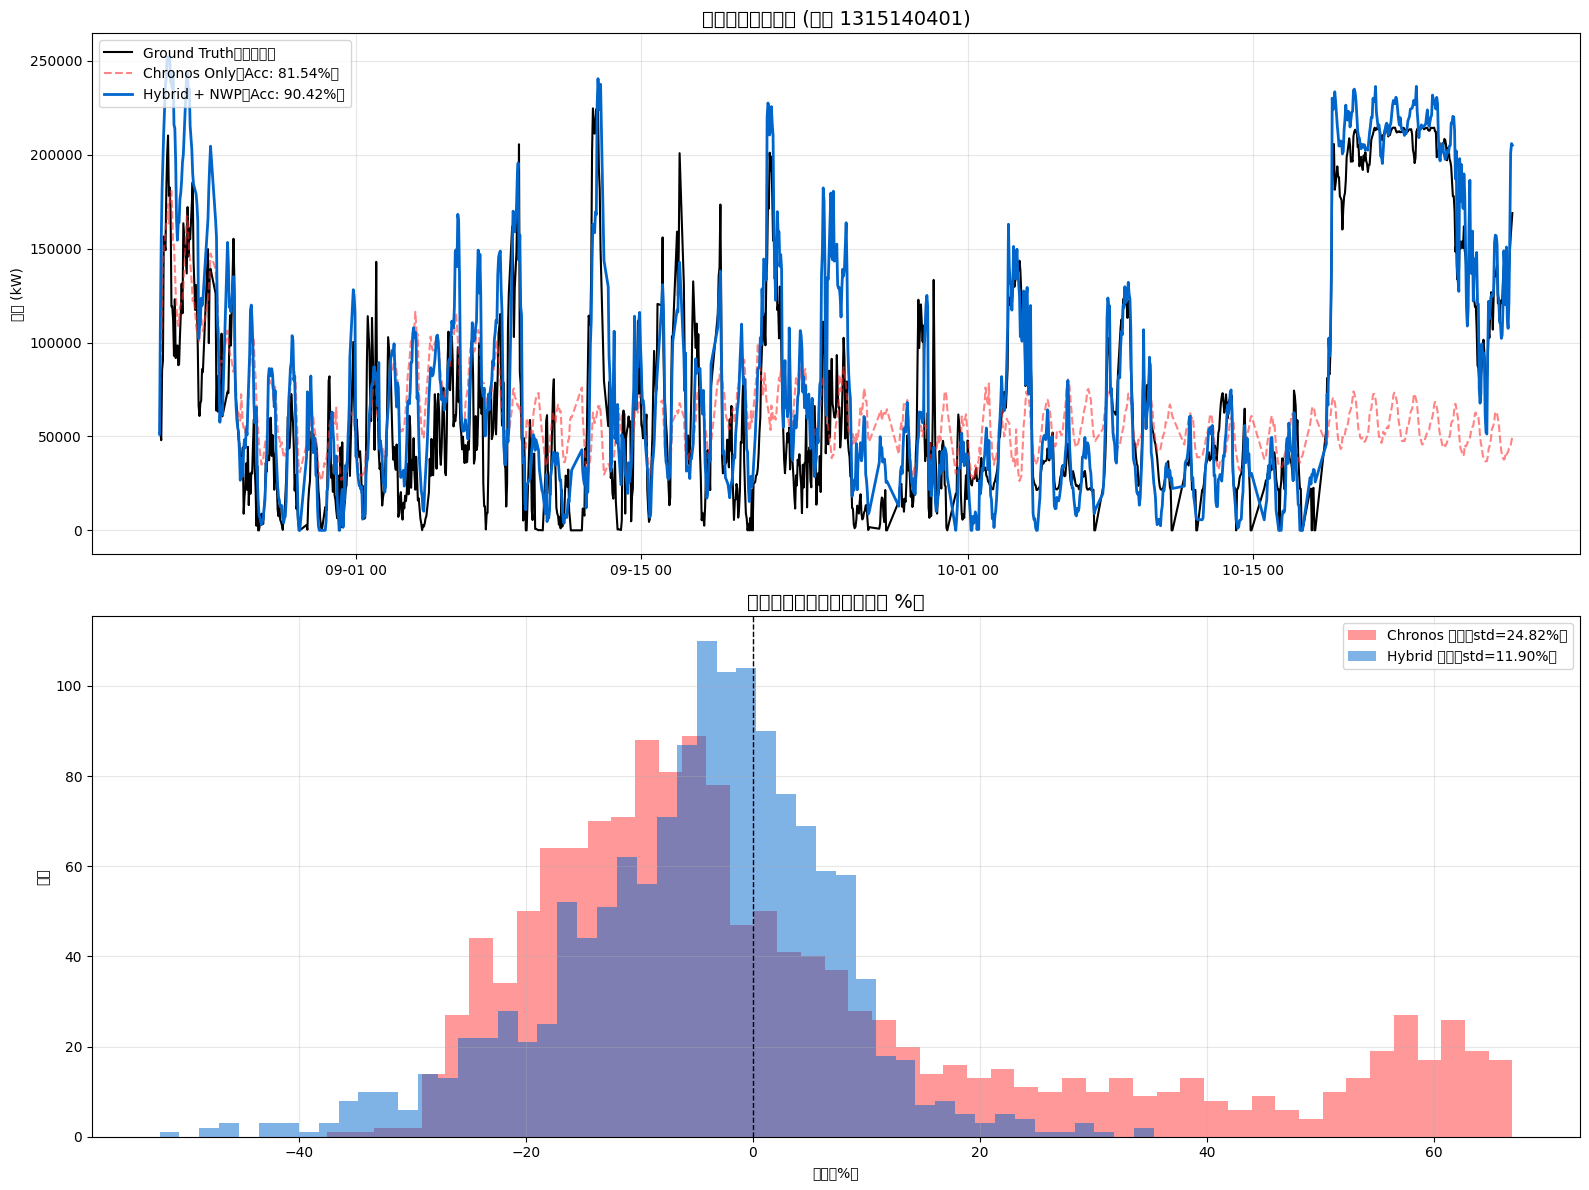

图表已保存至 /kaggle/working/forecast_result.png


In [3]:
# -*- coding: utf-8 -*-
"""
风电功率预测混合模型 - 优化版本 v3
修复内容：
  1. [关键] 修复验证集泄露：重新划分数据集，LightGBM 在独立子集上训练
  2. [关键] 加强数据清洗：过滤限电、停机、风速-功率异常数据
  3. [关键] 时间轴补全：NWP 特征只用前向填充（ffill），禁止线性插值（会用到未来值）
  4. [关键] 评估/训练前过滤 NaN：功率为 NaN 的时间点不参与残差计算和指标评估
"""

import gc
import torch
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error
from chronos import Chronos2Pipeline


# ==========================================
# 工具函数
# ==========================================
def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        torch.cuda.ipc_collect()


def reindex_to_full_timeline(df: pd.DataFrame, freq: str = "1h") -> pd.DataFrame:
    """
    按电站分组，把时间轴补全为等间距。
    - corrected_scada_power：缺口保留 NaN（不能凭空捏造真实功率）
    - NWP 气象特征：只用前向填充 ffill（最多填 3 步），
      绝对不能用线性插值，因为线性插值会用到未来时刻的值，
      而实际预测时未来 NWP 数据是拿不到的。
    """
    result_list = []
    for item_id, g in df.groupby("plantid"):
        g = g.set_index("date").sort_index()
        full_idx = pd.date_range(g.index.min(), g.index.max(), freq=freq)
        g = g.reindex(full_idx)
        g.index.name = "date"
        g["plantid"] = item_id

        # NWP 特征：仅前向填充，最多补 3 个连续缺口
        nwp_cols = [c for c in g.columns if c not in ["plantid", "corrected_scada_power"]]
        g[nwp_cols] = g[nwp_cols].ffill(limit=3)

        # 功率列保留 NaN，后续统一用 valid_mask 过滤

        result_list.append(g.reset_index())
    return pd.concat(result_list).reset_index(drop=True)


clear_gpu()

# ==========================================
# 核心超参数
# ==========================================
target_col  = "corrected_scada_power"
max_power   = 252000
CONTEXT_LEN = 192   # 回看 8 天
PRED_LEN    = 24    # 预测 24 小时
STRIDE      = 6     # 滑窗步长
WINDOW_SIZE = CONTEXT_LEN + PRED_LEN

# 数据清洗阈值
SHUTDOWN_WINDOW  = 3      # 连续 N 小时功率为 0 → 视为停机
SHUTDOWN_THRESH  = 0.01   # 功率低于额定 1% 视为零出力
CURTAIL_WIND_MIN = 0.35   # 风速系数高于此值
CURTAIL_POWER_MAX= 0.10   # 但功率低于此值 → 疑似限电
PC_DEVIATION_MAX = 0.40   # 功率偏离理论曲线超过此值 → 异常点

# 数据集划分比例
TRAIN_RATIO      = 0.70
LGBM_TRAIN_RATIO = 0.85
LGBM_VAL_RATIO   = 0.90
# TEST_RATIO = 剩余 10%


# ============================================================
# 第一阶段：读取数据
# ============================================================
print("=== 第一阶段：读取数据 ===")
file_path = "/kaggle/input/datasets/zhanyi1/dataset/qqqqqqqq20240103_20251102_1315140401.csv"
df = pd.read_csv(file_path)
df["plantid"] = df["plantid"].astype(str)
df["date"]    = pd.to_datetime(df["date"])
df = df.sort_values(by=["plantid", "date"]).reset_index(drop=True)

# 归一化到 [0, 1]
df[target_col] = df[target_col] / max_power
df[target_col] = np.clip(df[target_col], 0.0, 1.0)

print(f"原始数据量：{len(df)} 条")


# ============================================================
# 第二阶段：数据清洗
# ============================================================
print("\n=== 第二阶段：加强数据清洗 ===")


def theoretical_power_curve(ws):
    """
    三段式风机功率曲线，返回理论出力系数 [0, 1]
    ws: 原始风速 (m/s)
    """
    cut_in  = 3.0
    rated   = 12.0
    cut_out = 25.0
    return np.where(
        ws < cut_in,   0.0,
        np.where(
            ws > cut_out,  0.0,
            np.where(
                ws >= rated, 1.0,
                ((ws - cut_in) / (rated - cut_in)) ** 3
            )
        )
    )


cleaned_list = []
stats = {"original": 0, "after_curtail": 0, "after_shutdown": 0, "after_pc": 0}

for item_id, g in df.groupby("plantid"):
    g = g.sort_values("date").reset_index(drop=True)
    stats["original"] += len(g)

    # 清洗 1：过滤限电时段（高风速但功率极低）
    ws_proxy     = g["WS_100"] / 25.0
    is_curtailed = (ws_proxy > CURTAIL_WIND_MIN) & (g[target_col] < CURTAIL_POWER_MAX)
    g = g[~is_curtailed].reset_index(drop=True)
    stats["after_curtail"] += len(g)

    # 清洗 2：过滤停机时段（连续 N 小时零出力）
    is_near_zero        = (g[target_col] < SHUTDOWN_THRESH).astype(int)
    rolling_zero        = is_near_zero.rolling(SHUTDOWN_WINDOW, min_periods=SHUTDOWN_WINDOW).sum()
    is_shutdown         = (rolling_zero == SHUTDOWN_WINDOW)
    is_shutdown_shifted = is_shutdown.shift(1).fillna(False)
    g = g[~(is_shutdown | is_shutdown_shifted)].reset_index(drop=True)
    stats["after_shutdown"] += len(g)

    # 清洗 3：风速-功率曲线偏差过滤
    if "WS_100" in g.columns:
        theoretical  = theoretical_power_curve(g["WS_100"].values)
        pc_deviation = np.abs(g[target_col].values - theoretical)
        g = g[pc_deviation <= PC_DEVIATION_MAX].reset_index(drop=True)
    stats["after_pc"] += len(g)

    cleaned_list.append(g)

df = pd.concat(cleaned_list).reset_index(drop=True)

print(f"  原始数据：        {stats['original']:>8} 条")
print(f"  去限电后：        {stats['after_curtail']:>8} 条  （剔除 {stats['original']-stats['after_curtail']} 条）")
print(f"  去停机后：        {stats['after_shutdown']:>8} 条  （剔除 {stats['after_curtail']-stats['after_shutdown']} 条）")
print(f"  去功率曲线异常后：{stats['after_pc']:>8} 条  （剔除 {stats['after_shutdown']-stats['after_pc']} 条）")
print(f"  总清洗率：        {(1 - stats['after_pc']/stats['original'])*100:.1f}%")

# 补全时间轴（NWP 只前向填充，功率缺口保留 NaN）
print("补全时间轴，NWP 缺口前向填充，功率缺口保留 NaN...")
df = reindex_to_full_timeline(df, freq="1h")
print(f"补全后数据量：{len(df)} 条")


# ============================================================
# 第三阶段：划分数据集
# ============================================================
print("\n=== 第三阶段：划分数据集（train 70% | lgbm_train 15% | lgbm_val 5% | test 10%）===")

train_inputs                = []
lgbm_train_df_list          = []
lgbm_val_df_list            = []
test_df_list                = []
context_for_lgbm_train_list = []
context_for_lgbm_val_list   = []
context_for_test_list       = []

for item_id, g in df.groupby("plantid"):
    g = g.sort_values("date").reset_index(drop=True)
    n = len(g)

    train_end      = int(n * TRAIN_RATIO)
    lgbm_train_end = int(n * LGBM_TRAIN_RATIO)
    lgbm_val_end   = int(n * LGBM_VAL_RATIO)

    train_df      = g.iloc[:train_end]
    lgbm_train_df = g.iloc[train_end:lgbm_train_end]
    lgbm_val_df   = g.iloc[lgbm_train_end:lgbm_val_end]
    test_df       = g.iloc[lgbm_val_end:]

    lgbm_train_df_list.append(lgbm_train_df)
    lgbm_val_df_list.append(lgbm_val_df)
    test_df_list.append(test_df)

    context_for_lgbm_train_list.append(g.iloc[max(0, train_end - CONTEXT_LEN):train_end])
    context_for_lgbm_val_list.append(g.iloc[max(0, lgbm_train_end - CONTEXT_LEN):lgbm_train_end])
    context_for_test_list.append(g.iloc[max(0, lgbm_val_end - CONTEXT_LEN):lgbm_val_end])

    # 滑窗增强：只用功率非 NaN 的连续段
    train_series = train_df[target_col].values
    for i in range(0, len(train_series) - WINDOW_SIZE + 1, STRIDE):
        window = train_series[i: i + WINDOW_SIZE]
        if not np.any(np.isnan(window)):   # 跳过含 NaN 的窗口
            train_inputs.append({"target": window})

lgbm_train_all     = pd.concat(lgbm_train_df_list).reset_index(drop=True)
lgbm_val_all       = pd.concat(lgbm_val_df_list).reset_index(drop=True)
test_df_all        = pd.concat(test_df_list).reset_index(drop=True)
context_lgbm_train = pd.concat(context_for_lgbm_train_list).reset_index(drop=True)
context_lgbm_val   = pd.concat(context_for_lgbm_val_list).reset_index(drop=True)
context_test_df    = pd.concat(context_for_test_list).reset_index(drop=True)

print(f"  Chronos 微调样本数：{len(train_inputs)}")
print(f"  LightGBM 训练集大小：{len(lgbm_train_all)}")
print(f"  LightGBM 验证集大小：{len(lgbm_val_all)}")
print(f"  最终测试集大小：    {len(test_df_all)}")


# ============================================================
# 第四阶段：加载并微调 Chronos 2.0
# ============================================================
print("\n=== 第四阶段：微调 Chronos 2.0 ===")
model_dir = r"/kaggle/working/damoxing/chronos-2"
pipeline = Chronos2Pipeline.from_pretrained(
    model_dir, device_map="auto", torch_dtype=torch.bfloat16, local_files_only=True
)

finetuned_pipeline = pipeline.fit(
    inputs=train_inputs,
    prediction_length=PRED_LEN,
    context_length=CONTEXT_LEN,
    finetune_mode="full",
    batch_size=2,
    gradient_accumulation_steps=16,
    learning_rate=2e-5,
    num_steps=1000,
    logging_steps=100,
    tf32=False,
)


# ============================================================
# 第五阶段：构建气象 + 时间特征
# ============================================================
print("\n=== 第五阶段：构建特征 ===")
nwp_features = [
    'WS_100', 'WS_10', 'WS_200', 'u100', 'u10', 'u200',
    'v_600hPa', 'v_700hPa', 'tcc', 'r_925hPa', 'r_900hPa', 'u_1000hPa'
]
time_features     = ['hour', 'month']
all_lgbm_features = nwp_features + time_features

for df_temp in [lgbm_train_all, lgbm_val_all, test_df_all]:
    df_temp['hour']  = df_temp['date'].dt.hour
    df_temp['month'] = df_temp['date'].dt.month

# 选取第一个电站演示
item_id          = df["plantid"].iloc[0]
lgbm_train_chunk = lgbm_train_all[lgbm_train_all["plantid"] == item_id].copy()
lgbm_val_chunk   = lgbm_val_all[lgbm_val_all["plantid"] == item_id].copy()
test_chunk       = test_df_all[test_df_all["plantid"] == item_id].copy()


# ============================================================
# 第六阶段：Chronos 推理 → 残差计算 → 训练 LightGBM
# ============================================================
print("\n=== 第六阶段：Chronos 推理 + LightGBM 残差训练 ===")

# --- 6.1 推理 lgbm_train 段 ---
print("  Chronos 推理 lgbm_train 段...")
ctx_lgbm_train     = context_lgbm_train[context_lgbm_train["plantid"] == item_id]
lgbm_train_pred_df = finetuned_pipeline.predict_df(
    ctx_lgbm_train,
    prediction_length=len(lgbm_train_chunk),
    context_length=CONTEXT_LEN,
    quantile_levels=[0.5],
    id_column="plantid",
    timestamp_column="date",
    target=target_col,
    batch_size=4,
)
chronos_lgbm_train_pred = lgbm_train_pred_df["0.5"].values * max_power
lgbm_train_true         = lgbm_train_chunk[target_col].values * max_power

# 过滤功率 NaN（时间轴补全的缺口）
train_valid            = ~np.isnan(lgbm_train_true)
lgbm_train_chunk_clean = lgbm_train_chunk[train_valid].copy()
train_residuals        = lgbm_train_true[train_valid] - chronos_lgbm_train_pred[train_valid]
print(f"  lgbm_train 有效点：{train_valid.sum()} / {len(train_valid)}")

# --- 6.2 推理 lgbm_val 段 ---
print("  Chronos 推理 lgbm_val 段...")
ctx_lgbm_val     = context_lgbm_val[context_lgbm_val["plantid"] == item_id]
lgbm_val_pred_df = finetuned_pipeline.predict_df(
    ctx_lgbm_val,
    prediction_length=len(lgbm_val_chunk),
    context_length=CONTEXT_LEN,
    quantile_levels=[0.5],
    id_column="plantid",
    timestamp_column="date",
    target=target_col,
    batch_size=4,
)
chronos_lgbm_val_pred = lgbm_val_pred_df["0.5"].values * max_power
lgbm_val_true         = lgbm_val_chunk[target_col].values * max_power

val_valid            = ~np.isnan(lgbm_val_true)
lgbm_val_chunk_clean = lgbm_val_chunk[val_valid].copy()
val_residuals        = lgbm_val_true[val_valid] - chronos_lgbm_val_pred[val_valid]
print(f"  lgbm_val 有效点：{val_valid.sum()} / {len(val_valid)}")

# --- 6.3 训练 LightGBM（含早停）---
print("  训练 LightGBM 残差修正模型（含早停）...")
lgb_train_set = lgb.Dataset(
    lgbm_train_chunk_clean[all_lgbm_features], label=train_residuals
)
lgb_val_set = lgb.Dataset(
    lgbm_val_chunk_clean[all_lgbm_features], label=val_residuals,
    reference=lgb_train_set
)

params = {
    'objective':        'regression',
    'metric':           'mae',
    'learning_rate':    0.05,
    'max_depth':        7,
    'num_leaves':       63,
    'feature_fraction': 0.8,
    'verbose':          -1,
    'random_state':     42,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=50),
]

gbm = lgb.train(
    params,
    lgb_train_set,
    num_boost_round=500,
    valid_sets=[lgb_val_set],
    callbacks=callbacks,
)
print(f"  LightGBM 最优迭代轮数：{gbm.best_iteration}")


# ============================================================
# 第七阶段：测试集预测
# ============================================================
print("\n=== 第七阶段：测试集预测 ===")

# 7.1 Chronos 推理测试集
ctx_test     = context_test_df[context_test_df["plantid"] == item_id]
test_pred_df = finetuned_pipeline.predict_df(
    ctx_test,
    prediction_length=len(test_chunk),
    context_length=CONTEXT_LEN,
    quantile_levels=[0.5],
    id_column="plantid",
    timestamp_column="date",
    target=target_col,
    batch_size=4,
)
chronos_test_baseline = test_pred_df["0.5"].values * max_power

# 7.2 LightGBM 残差补偿
predicted_residuals = gbm.predict(test_chunk[all_lgbm_features])

# 7.3 融合 + 物理约束
final_hybrid_predictions = chronos_test_baseline + predicted_residuals
final_hybrid_predictions = np.clip(final_hybrid_predictions, 0, max_power)


# ============================================================
# 第八阶段：评估与可视化
# ============================================================
print("\n=== 第八阶段：评估结果 ===")
y_true_test = test_chunk[target_col].values * max_power

# 过滤 NaN（时间轴补全引入的缺口不参与评估）
valid_mask       = ~np.isnan(y_true_test)
y_true_eval      = y_true_test[valid_mask]
chronos_eval     = chronos_test_baseline[valid_mask]
hybrid_eval      = final_hybrid_predictions[valid_mask]
test_dates_eval  = test_chunk['date'].values[valid_mask]

print(f"  测试集总点数：{len(y_true_test)}，有效点数：{valid_mask.sum()}，NaN 点数：{(~valid_mask).sum()}")

chronos_mae  = mean_absolute_error(y_true_eval, chronos_eval)
hybrid_mae   = mean_absolute_error(y_true_eval, hybrid_eval)
chronos_rmse = np.sqrt(mean_squared_error(y_true_eval, chronos_eval))
hybrid_rmse  = np.sqrt(mean_squared_error(y_true_eval, hybrid_eval))

chronos_accuracy = (1 - chronos_mae / max_power) * 100
hybrid_accuracy  = (1 - hybrid_mae  / max_power) * 100

print(f"  {'指标':<20} {'Chronos Only':>15} {'Hybrid':>15} {'提升':>10}")
print(f"  {'-'*60}")
print(f"  {'准确率 (%)'::<20} {chronos_accuracy:>15.2f} {hybrid_accuracy:>15.2f} {hybrid_accuracy-chronos_accuracy:>+10.2f}")
print(f"  {'MAE (kW)'::<20} {chronos_mae:>15.1f} {hybrid_mae:>15.1f} {hybrid_mae-chronos_mae:>+10.1f}")
print(f"  {'RMSE (kW)'::<20} {chronos_rmse:>15.1f} {hybrid_rmse:>15.1f} {hybrid_rmse-chronos_rmse:>+10.1f}")

# --- 可视化 ---
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

ax1 = axes[0]
ax1.plot(test_dates_eval, y_true_eval,
         label="Ground Truth（真实值）", color="black", linewidth=1.5)
ax1.plot(test_dates_eval, chronos_eval,
         label=f"Chronos Only（Acc: {chronos_accuracy:.2f}%）",
         color="#FF3333", linestyle="--", alpha=0.6)
ax1.plot(test_dates_eval, hybrid_eval,
         label=f"Hybrid + NWP（Acc: {hybrid_accuracy:.2f}%）",
         color="#0066CC", linewidth=2.0)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H"))
ax1.gcf = lambda: fig
ax1.set_title(f"风电功率预测对比 (电站 {item_id})", fontsize=14)
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)
ax1.set_ylabel("功率 (kW)")

ax2 = axes[1]
chronos_errors = y_true_eval - chronos_eval
hybrid_errors  = y_true_eval - hybrid_eval
ax2.hist(chronos_errors / max_power * 100, bins=50, alpha=0.5,
         label=f"Chronos 误差（std={np.std(chronos_errors / max_power * 100):.2f}%）",
         color="#FF3333")
ax2.hist(hybrid_errors / max_power * 100, bins=50, alpha=0.5,
         label=f"Hybrid 误差（std={np.std(hybrid_errors / max_power * 100):.2f}%）",
         color="#0066CC")
ax2.axvline(0, color="black", linestyle="--", linewidth=1)
ax2.set_title("预测误差分布（占额定功率 %）", fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlabel("误差（%）")
ax2.set_ylabel("频次")

plt.tight_layout()
plt.savefig("/kaggle/working/forecast_result.png", dpi=150, bbox_inches="tight")
plt.show()
print("图表已保存至 /kaggle/working/forecast_result.png")